# Using Memory-Based State Estimators

In [1]:
#| hide
from nbdev import show_doc
import math

# Introduction

In this tutorial, we show how to use a series of increasingly complex memory graphs as the basis for Bayesian updates to a belief about the state of an external environment.

In the simplest memory graph,  'Sequence Memory', we model the memorization of an exact sequence of percepts through the encoding of percepts into memory traces (the graph nodes). We will show how this memory graph can be used to establish the probability that an external environment has returned to the exact state or sequence of states that produced the memorized sequence.

We add a level of complexity in 'Short-Term Memory', which models the 'fading' of information encoded in memory traces. We will show how this fading is comparable to forming a coarse-grained model of the world, making state estimation on the memory graph more robust to noisy signals.

'Long-Term Memory' builds further complexity by modeling (1) how the surprise of each percept mediates the fading rate of the memory trace to which it is encoded and (2) how 're-activation' of a memory trace consolidates the memory by slowing the fading rate of that trace. We will show how this allows the memory graph to prioritize the retention and re-activation of relevant memory traces, setting the stage for learning efficient representations of the external environment

Finally, with 'Associative Memory', we model the plasticity of memory traces upon re-activation. We will show how this plasticity allows the memory graph to learn and use efficient represetations of the external environnment for estimating the current state of that environment.

# Background - Series Recognition

Throughout this tutorial, we will use an experimental paradigm from psychology called "Series Recognition" to illustrate the functionality of each memory graph and the aspects of memory which it is said to model. In a Series Recognition task, a human or animal subject is presented with a series of items (i.e. a list). After a period of time known as a 'retention interval', the subject is presented with another item ('probe') and asked to identify whether or not that item was in the recently preseneted list. In cases where the probe matches an item from the recently presented list ('target'), the probability that both humans and animals answer correctly depends both on the position of the target in the list (e.g. first, second, fifth, last, etc.) and the length of the retention interval. Subjects are more likely to accurately recognize items presented earlier ('primacy effect') and items presented toward the end of the list ('recency effect') than items in the middle. For short retention intervals, the recency effect is much stronger than the primacy effect; as the retention interval increases, the recency effect reduces to the point of vanishing while the primacy effect remains consistent or increases. 

This interaction is widely regarded as evidence of a process of memory traces (sometimes 'stimulus traces') in short-term memory either being forgotten or transferred to long-term memory. We will use simulated environments that emulate a Series Recognition task to illustrate how each kind of memory graph builds toward a system of memory that both reproduces these effects and also learns efficient representations of the environment that can be used to make predictions about the future.

# Sequence Memory

With the "Sequence Memory" memory graph, we introduce the key concepts of memory-based state estimation. These key concepts are (1) The Memory-Environment Interface, (2) The Stationary Hypothesis, (3) Memory Traces, and (4) Bayesian Filtering. We will show that with these concepts, Sequence Memory can be usefully applied for state estimation in certain environments that align with the implicit biases of Sequence Memory.

## The Memory-Environment Interface

In the general Projective Simulation framework, an agent is said to interact with its environment through a percept-action loop. In this loop, the environment has a state which is updated as a function of the agent's action. This new environment state produces a percept, and the agent then updates its own state as a function of this percept before producing a new action. Because we are particularly interested in the *embodied* nature of agency, we think of that part of the agent which 'receives' the percept and 'transmits' the action as the agent-environment interface.

In this work, we consider a memory graph as a component of such an agent - a component that may form the basis of an Episodic and Compositional Memory. This memory graph takes as input the same percept as the agent and updates its state likewise. Because we do not explicitly model the production of an action by the agent here, we consider the memory-environment interface to be identical the agent-environment *sensory* interface. An important aspect of our memory graphs is that they decompose a percept into constituent parts - one can think of each percept 'category' being converted to the state of a corresponding sensor in the memory-environment interface.

To define a memory-graph, then, the first thing one must define is the number of sensors in the memory-environment interface and the number of states each sensor can take. This information is passed to the Sequence_Memory constructor as the argument 'category_sizes'. We will cover the other arguments to Sequence_Memory next.

In [2]:
from projective_simulation.ECMs.state_estimators import Sequence_Memory

In [3]:
show_doc(Sequence_Memory)

---

[source](https://github.com/{user}/projective_simulation/blob/master/projective_simulation/ECMs/state_estimators.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### Sequence_Memory

>      Sequence_Memory (category_sizes:list[int], memory_capacity:int,
>                       memory_bias:float, stationary_expectations:numpy.ndarray
>                       [typing.Any,numpy.dtype[numpy.float64]]=None, sensory_pr
>                       edictions:numpy.ndarray[typing.Any,numpy.dtype[numpy.flo
>                       at64]]=None, belief_prior:numpy.ndarray[typing.Any,numpy
>                       .dtype[numpy.float64]]=None, transition_predictions:nump
>                       y.ndarray[typing.Any,numpy.dtype[numpy.float64]]=None,
>                       timer:int=0, capacity_overflow_method:str='stop
>                       encoding', data_record:list[str]=[],
>                       record_until:int=-1,
>                       stationary_transition_method:str='first')

*Memory-based Bayesian filter that encodes a sequence of percepts as memory traces.
Each memory trace is a hypothesis about the environment, and the agent can transition between non-memory and memory hypotheses. 
Memory traces are encoded by dynamic modification of transition function and observation function.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| category_sizes | list |  | Number of states for each sensor/percept category. |
| memory_capacity | int |  | Number of memory-based hypotheses. |
| memory_bias | float |  | Probability of transitioning from non-memory to memory hypothesis space. |
| stationary_expectations | ndarray | None | Expectation of sensory states in stationarity. Default to uniform distributions for each sensor. |
| sensory_predictions | ndarray | None | Sensory hypotheses matrix. If None, initialized to uniform. |
| belief_prior | ndarray | None | Initial belief priors. If None, all prior on non-memory hypothesis. |
| transition_predictions | ndarray | None | Hypothesis transition matrix. |
| timer | int | 0 | Starting memory time index. |
| capacity_overflow_method | str | stop encoding | 'loop' or 'stop encoding'. |
| data_record | list | [] | List of variable names to log each time step. Accepts "all". |
| record_until | int | -1 | Number of steps to prepare for data logging. Negative disables recording. |
| stationary_transition_method | str | first | 'encoded', 'first', or 'learned'. |

## The Stationary Hypothesis

The goal of a memory graph is to build a predictive model of the environment for an agent that has no prior knowledge about the structure of the environment, i.e. the states of the environment that exist and how they relate to each other and to the agent's percepts. To achieve this, it is helpful to assume the agent 'inherits' some knowledge about general properties of its environment; what we might call *implicit biases*. In our case, we assume that the agent inherits knowledge of the overall probability that any given state in the environment yields a given state for any sensor - or at least a rough approximation thereof. This knowledge is represented in a memory graph by what we call the "stationary hypothesis". To define the stationary hypothesis, one must pass a 1D numpy array to the argument stationary_expectations of the Sequence_Memory constructor that contains these probabilities. These probabilites must be ordered such that the first $N_1$ elements represent the probability distribution over the $N_1$ possible states of the first sensor, as defined by *category_sizes*; the next $N_2$ elements give the probability distribution over the possible states of the second sensor, and so-on and so-forth for all sensors indicated by the length of the *category_sizes* list. An example is provided below.

In [4]:
import numpy as np

In [5]:
#Define a memory-environment interface with two sensors, each of which can take two states
category_sizes = [2,2]

#Define stationary_expectations for the above memory-environment interface.
#The resulting implicit bias is that both states of the first sensor are equally common, 
#but the first state of the second sensor occurs 9x more frequently, overall, than the second state.
stationary_expectations_good = np.array([0.5,0.5,0.9,0.1])

#Some examples of invalid stationary_expectations. 
#These would raise Value Errors if initialization of Sequence_Memory was attempted
stationary_expectations_bad1 = np.array([0.5,0.5,0.8,0.1]) #expectations on the second sensor do not yield a valid probability distribution
stationary_expectations_bad2 = np.array([0.5,0.5,0.6,0.3,0.1]) #the total number of possible states does not align with category_sizes

In [6]:
#Initialize Valid Sequence Memory
toy_sequence_memory_graph = Sequence_Memory(
    category_sizes=category_sizes,
    stationary_expectations=stationary_expectations_good,
    memory_capacity=5, #to be explained next
    memory_bias = 0.05 #to be explained subsequently
)
toy_sequence_memory_graph

## Memory Traces

### Encoding Percepts and Sensory Predictions

To begin, the only information a memory graph has about the environment comes from its stationary hypothesis - but it can acquire more information by storing information about its percepts into a **memory trace**. The Sequence Memory graph will store the first $C$ many percepts it receives to memory traces, where $C$ is its *memory capacity*. The percept is initially stored as a set of **one-hot encodings** in the same structure as the expectations encoded by the stationary hypothesis. That is to say, as a 1D array where the first $N_1$ elements are a one-hot encoding of the state of the first percept category/sensor, so-on and so-forth for all percept categories/sensors. 

The combination of the memory graph's memory traces and its stationary hypothesis form the memory graph's **hypothesis space** about its **situation** in the environment. We use situation to mean the set of world states (the joint state of the environment and the agent or memory graph) that yield the same effective future for the agent or memory graph's interface with the environment, i.e. the future percepts of the memory graph. For a Sequence Memory graph, one can think of a memory trace as representing the hypothesis that "my situation is the same as when the percept stored in this trace was encoded." The Stationary Hypothesis can be understood to represent the hypothesis "my situation is not the same as it was when the percepts stored in any of my memory traces were encoded." 

The percept information encoded in each of these hypotheses, then, can be understood as a prediction about the state of each sensor/percept category given that the hypothesis is true. In a Sequence_Memory instance, these predictions are stored in the *sensory_predictions* matrix. We can see in our toy instantiation that this matrix is initialized with predictions for each of the five memory traces it has the capacity to encode that are identical to the predictions of its stationary hypothesis.

In [7]:
toy_sequence_memory_graph.sensory_predictions
#The first five rows of this matrix give the sensory predictions of the five memory traces available to the memory graph.
#The last row gives the sensory predictions of the stationary hypothesis.
#Initially, these are all identical.

array([[0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1]])

If we pass a percept to the Sequence Memory graph using its *sample* method, we can see how the first memory trace changes to a one-hot encoding of the percept.

In [8]:
percept1 = np.array([1,0])
toy_sequence_memory_graph.sample(percept1)
toy_sequence_memory_graph.sensory_predictions

array([[0. , 1. , 1. , 0. ],
       [0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1]])

The default Sequence Memory stops encoding percepts to memory traces after it has used all available traces. We discuss alternative methods in the "further modelling considerations" section.

### Encoding Hypothesis Transitions and Memory Bias

Each of the memory graph's hypotheses store information about sensor state probabilities, given the hypothesis is true, and about the proability that any other hypothesis will be true when the *next* percept is recieved. For a Sequence Memory Graph, this these transition predictions can be specified on initialization and does not change. The predicted probability of transitioning from one memory trace hypothesis to another is always $1$ if the second memory trace was encoded immediately after the first and $0$ otherwise. This reflects another implicit bias of the Sequence Memory graph: the assumption that situations follow a deterministic cycle (this assumption will be relaxed in other memory graphs). We can see that these predictions are already set up in the toy Sequence Memory's *transition_predictions*.

In [9]:
toy_sequence_memory_graph.transition_predictions

array([[0.  , 1.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 1.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 1.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 1.  ],
       [0.05, 0.  , 0.  , 0.  , 0.  , 0.95]])

What about the transition predictions of the stationary hypothesis, given by the last row of the matrix? These are defined by the *memory bias*, the last required argument for initializing a Sequence Memory instance. One can see that for a Sequence Memory graph, the memory bias gives the probability with which the stationary hypothesis predicts the memory graph's next situation will be the same as it's situation when its first memory was encoded. This probability reflects an implicit bias of the Sequence Memory graph regarding the assumed size of the environment's state space. In the case of our toy instance, for example, we can determine that the memory bias implies an expectation that the memory graph will move through a deterministic cycle of twenty-five situations. Why? The memory graph can encode five situations to memory, then must rely on its stationary hypothesis to represent the rest. If there are twenty such remaining situations, and all the memory graph 'knows' if its stationary hypothesis is true is that it is in one of those situations, then the probablility that it is in the situation that precedes the situation represented by its first memory trace is 0.05. It can not transition to situations represented by other memory traces because it remembers the situations that preceded each and - if its stationary hypthesis is true - knows that it is not in any of those situations.

## Bayesian Filtering

The set of implicit biases used to define a Sequence Memory graph are quite strong - and likely not particularly useful for real embodied agents - but the resulting simplicity is useful for demonstrating and understanding the core mechanisms of all memory graphs: Bayesian filtering. The goal of Bayesian filtering is to establish a **belief state**, i.e. a probability distribution over a set of exhaustive and mutually exclusive hypotheses, and to update this belief state with each new observation. Here, observations take the form of percepts/sensory states. To illustrate how it works, we will initialize a new Sequence Memory instance and look at how it behaves in an environment we call the List Sequencer.



### Setting up a List Sequencer Environment

The List Sequencer produces two kinds of percepts: "list items" and "timeouts". During a timeout, all percept categories are set to state '0'. During the presentation of a list, all percept category states are non-zero. The user can define how many percept categories there are (*item_size*) and the number of states a percept category can take when a list item is presented (*item_category_size*). The number of sequentially presented list items in each list is fixed (*series_length*), while the length of each timeout period between lists is drawn from a binomial distribution. This set-up serves as the foundation for simulating the classic series recognition task, which we explore in another tutorial. Here, we will examine only how memory graphs - starting with Sequence Memory - behave when presented with the percepts generated by the list sequencer. Let's look at a simple example of such a percept sequence.

In [10]:
from projective_simulation.envs.factorized_POMDPs import List_Sequencer

In [11]:
show_doc(List_Sequencer)
#'series' is used interchangeably with 'list'

---

[source](https://github.com/{user}/projective_simulation/blob/master/projective_simulation/envs/factorized_POMDPs.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### List_Sequencer

>      List_Sequencer (item_size:int, item_category_size:int, series_length:int,
>                      reuse_items:bool=True, stimulus_duration:int=1,
>                      mean_timeout_interval:float=4,
>                      var_time_out_interval:float=2, num_series:int=3,
>                      seed:Optional[int]=None, enable_probe:bool=False)

*A factorized POMDP that produces a specific percept sequence that emulates classic series recognition tasks of human and animal memory*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| item_size | int |  | number of percept categories per item (K) |
| item_category_size | int |  | number of valid values per category (C), values are 1..C |
| series_length | int |  | items per series |
| reuse_items | bool | True | If true, items can be reused in different lists. Items are never reused for the same list |
| stimulus_duration | int | 1 | time steps for which an item (or probe stimulus) is presented |
| mean_timeout_interval | float | 4 | μ: desired mean timeout length (Binomial) |
| var_time_out_interval | float | 2 | σ²: desired variance (should be < μ for Binomial under-dispersion) |
| num_series | int | 3 | number of series to present |
| seed | Optional | None | random seed for reproducibility (use the same seed to reproduce) |
| enable_probe | bool | False | if True, adds a state to each percept category for a probe cue stimulus, enabling probe recognition |

In [12]:
#Set up a simple series List_Sequencer environment

#For the sake of an illustrative example, we intentionally select a seed that produces a short sequence in which the first list repeats
seed = 110

item_size = 1
item_category_size = 3
series_length = 3
num_series = 4
mean_timeout_interval = 2
var_timeout_intervel = 1

example_lists = List_Sequencer(
    item_size, 
    item_category_size, 
    series_length,
    mean_timeout_interval=mean_timeout_interval,
    var_time_out_interval=var_timeout_intervel,
    num_series=num_series,
    seed = seed
    )

example_lists.percept_sequence

array([[1],
       [3],
       [2],
       [0],
       [1],
       [2],
       [3],
       [0],
       [0],
       [3],
       [2],
       [1],
       [0],
       [0],
       [1],
       [3],
       [2]])

### Simulating A Memory Graph

Now that we have a percept sequence, we can simulate the memory graph observing each percept. Let's simulate a sequence memory that only has enough capacity to remember the first list.

In [13]:
#~~Set up Sequence Memory parameters~~
percept_category_sizes = [item_category_size + 1] #add one state for timeout

#we give the true stationary distribution of percept category states in the generating environment to the sequence memory as its stationary expectations
#We get this by taking the matrix product of the stationary state distribution and the observation matrix (probability of each sensor state given each env state)
stationary_expectations = example_lists.get_stationary_state_distribution() @ example_lists.factorized_observation_function
memory_capacity = series_length

#In this simple Sequence Memory example, it is possible to derive a 'correct' memory bias. 
#We will do so here to illustrate the concept, but in general the memory bias can be an approximation.
possible_lists = math.perm(item_category_size ** item_size, series_length) #K choose N (order matters, no replacement), where N is series_length and K is the number of possible items
avg_percepts_per_list = series_length + mean_timeout_interval
total_situations = possible_lists * avg_percepts_per_list
encodable_situations = memory_capacity
memory_bias = 1/(total_situations - encodable_situations)
#~~End parameter setup~~

#intilize Sequence_Memory
example_seq_memory = Sequence_Memory(percept_category_sizes, memory_capacity, memory_bias,stationary_expectations)
#set up data storage (records, for example, surprise and belief state at each time step)
num_percepts = np.shape(example_lists.percept_sequence)[0]
example_seq_memory.prepare_data_storage(data_record = ["all"], record_until = num_percepts) 

#Simulate
for i in range(num_percepts):
    percept = example_lists.percept_sequence[i,:]
    example_seq_memory.sample(percept)


Let us first look at the structure of the Sequence Memory graph after the simulation. Each row of the heatmaps below can be read as the conditional probability of some prediction (an observed sensory state, or the next situation) given the hypothesized situation. Note that the sensory predictions encode the first three percepts, and that there is a small probability of transitioning from the stationary hypothesis to the first memory hypothesis, given by the memory bias.

In [14]:
from projective_simulation.methods.visualization import plot_heatmap, memory_filter_performance
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

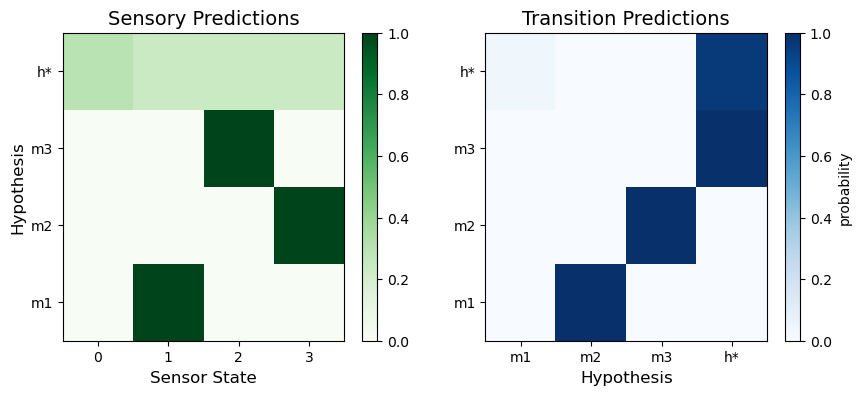

In [15]:
#Set Up Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

#plot sensory predictions
plot_heatmap(
    example_seq_memory.sensory_predictions,
    title = "Sensory Predictions",
    xlabel = "Sensor State",
    xtick_labels= ["0","1","2","3"],
    ylabel = "Hypothesis",
    ytick_labels= ["m1", "m2", "m3", "h*"], #We will use 'h*' to denote the stationary hypothesis,
    color = "Greens",
    ax = ax1)

#plot transition predictions
plot_heatmap(
    example_seq_memory.transition_predictions,
    title = "Transition Predictions",
    xlabel = "Hypothesis",
    xtick_labels= ["m1", "m2", "m3", "h*"],
    ylabel = None,
    ytick_labels= ["m1", "m2", "m3", "h*"],
    colorbar_kwargs={"label": "probability"},
    color = "Blues",
    ax = ax2)

plt.tight_layout
pass

### The Belief State

Now let us look at the posterior belief state over the course of the simulation. In the heatmap below, each row contains the probability with which with the Sequence Memory believes each hypothesis to be true at a given time step, after observing the new percept. To the left of the heatmap is the percept sequence. To the right of the graph is the surprise of the Sequence Memory when the percept was recieved (more on this later)

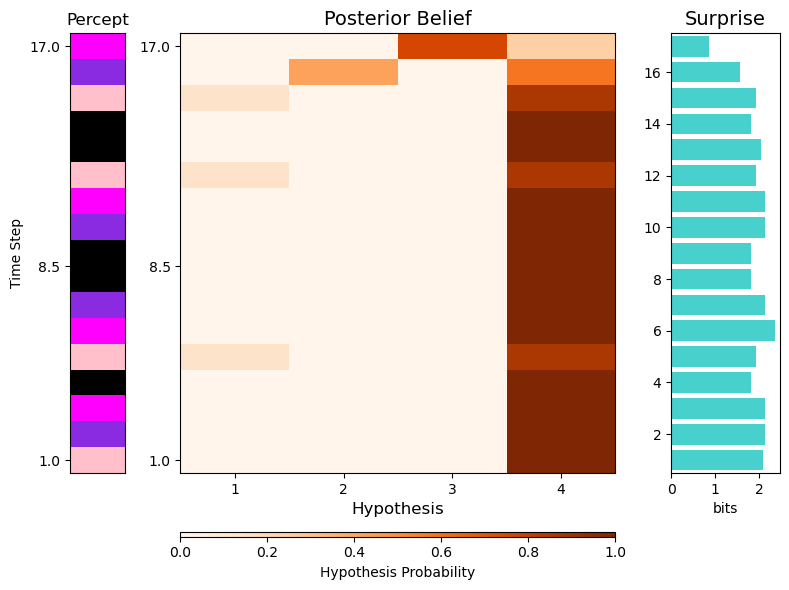

In [16]:
colormap = ('black', 'pink', 'fuchsia', 'blueviolet') #assign colors to each sensor state

memory_filter_performance(
    memory_data = example_seq_memory.data_dic, #data_dic is where memory graphs store the data indicated by the data_record argument
    observed_percepts=example_lists.percept_sequence,
    colormap = colormap,
    ) 

How does this work? The Sequence Memory begins with an initial belief that the probability of the stationary hypothesis is $1$ (it has no encoded memories to provide an alternative hypothesis). When it recieves a percept, a memory graph performs a **Bayesian Update** by multiplying the prior probability of each hypothesis by the likelihood of the percept given that the hypothesis is true, then renormalizing these products over the hypothesis space. This is the **posterior belief**. A new **prior belief** can then be computed by multiplying posterior probabilities of each hypothesis by the probabilites in the transition predictions.

The key idea of a Bayesian Filter, as just described, is that the history of percepts is not needed to maintainand accurate belief state (the vector of values that alternates between the prior belief and posterior belief), given that the hypotheses and their predictions provide an accurate hidden markov model of the environmental process.

The central motivation in creating the memory graphs presented in this tutorial is to acknowledge that embodied agents do not intially possess such a model, but that they might still retain memory of past percepts as a means of building one. We aim to understand how such a model can be constructed accurately across a range of environments, despite limitations on memory capacity, and how agents might continue to act and survive in the world even as as such a model is being learned.

## The Value of Sequence Memory

In this tutorial so far, we have shown how Sequence Memory stores a percept to a memory trace by creating a one-hot encoding of that percept, The structure of that one-hot encoding is determined by a representation of the possible states of the Memory-Environment Interface. The Sequence Memory encodes as many percepts to memory as it has capacity, and then stops encoding percept to memory traces - becoming static. Given appropriate implicit biases about the stationary distribution of sensor states and the number of situations that the memory graph lacks the capacity to encode, the belief state of Sequence Memory accurately reflects the probability that it has returned to the sequence of situations during which it was encoding memories.

The Sequence Memory graph is largely meant to demonstrate the probability theory foundations on which the next memory graphs are built, but it is not without value of its own. Similar systems may help embodied agents to imprint important patterns in early life, such as the presence of a parent, or the entrance to a central home/nest/den/hive/etc.

## Further Modelling Considerations
### Relaxing the definition of 'Situation'

In introducing Sequence Memory, transitions from the stationary hypothesis to any memory-based hypothesis other than the first were not allowed. This reflects a view of the world where situations, as represented by memory traces, are defined as sets of states with both identical future percepts *and* identical past percepts. If one relaxes the assumption that all environment states belonging to the same situtation have the same perceptual past, it opens the possibility of transitioning from an unremembered situtation to a situation represented by a memory trace other than the first. This can be modelled using Sequence Memory by setting the *stationary_transition_method* to "encoded" (allows transition to all encoded memories, as opposed the default "first"). Let us look at how this changes the posterior beliefs of a Sequence Memory given the same percept sequence as before

In [17]:
seq_memory2 = Sequence_Memory(
    percept_category_sizes, 
    memory_capacity, 
    memory_bias,
    stationary_expectations,
    stationary_transition_method = 'encoded')
seq_memory2.prepare_data_storage(data_record = ["all"], record_until = num_percepts) #this will store the belief state at every time step

#Simulate
for i in range(num_percepts):
    percept = example_lists.percept_sequence[i,:]
    seq_memory2.sample(percept)

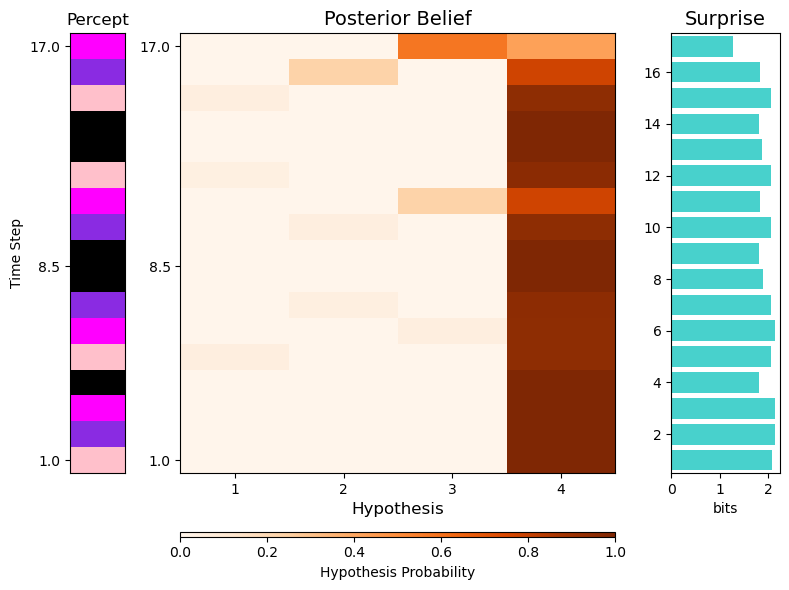

In [18]:
memory_filter_performance(seq_memory2.data_dic,example_lists.percept_sequence,colormap)

Posterior probability is now assigned to a memory trace any time the current percept matches the one encoded in that memory trace - even if preceding percepts do not match. As before, the posterior belief weight increases as a sequence of percepts matches a stored sequence. Note that the memory bias is divided across encoded memories, reducing the initial posterior belief probability when a matching percept is encountered.

In [19]:
print(np.round(seq_memory2.transition_predictions, decimals=3))

[[0.    1.    0.    0.   ]
 [0.    0.    1.    0.   ]
 [0.    0.    0.    1.   ]
 [0.012 0.012 0.012 0.963]]


### Encoding recent vs. first percepts

One can also allow Sequence Memory to continue encoding new memories after its capacity has been reached by overwriting the oldest memory trace. This is done by setting the *capacity_overflow* parameter to 'loop'. However, this is the default setting for the next kind of memory graph, Short-Term Memory, which we introduce now. In general, we recommend using a Short-Term Memory graph to model memory of recent percepts, as opposed to early, formative percepts.

## When Sequence Memory Fails

Whether Sequence Memory is used to encode recent or formative percepts, it uses one-hot encodings as sensory predictions; this requires that the perceptual futures of situations encoded by a memory trace must be *exactly identical*, not *probabilistically equivalent*. 

Consider how the posterior belief of a Sequence Memory graph behaves if noise is added to the example percept sequence used in the previous section.

In [20]:
#Add a noisy percept category to previous percept sequence
np.random.seed(1617031025)
noisy_states = 2
noisy_percept_category_sequence = np.random.choice(a = noisy_states, size = num_percepts) #randomly sample 0s and 1s
noisy_percept_sequence = np.concatenate((example_lists.percept_sequence, noisy_percept_category_sequence[:,np.newaxis]), axis = 1)
noisy_percept_sequence

array([[1, 1],
       [3, 1],
       [2, 1],
       [0, 1],
       [1, 0],
       [2, 0],
       [3, 1],
       [0, 0],
       [0, 1],
       [3, 1],
       [2, 1],
       [1, 0],
       [0, 1],
       [0, 1],
       [1, 1],
       [3, 1],
       [2, 0]])

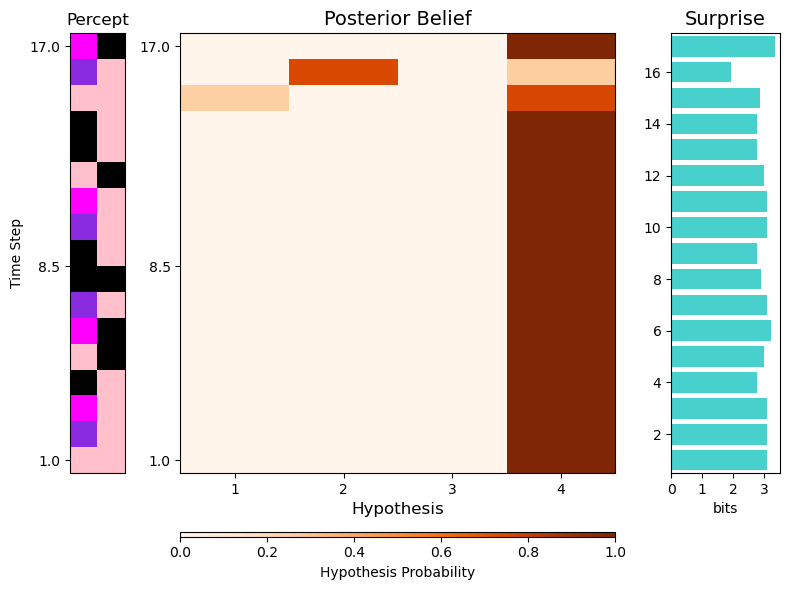

In [21]:
#Set Up Sequence Memory
new_percept_category_sizes = percept_category_sizes + [noisy_states]
new_stationary_expectations = np.concatenate((stationary_expectations, np.array([1/noisy_states] * noisy_states))) #add stationary expectations for new percept category

seq_memory_noisy = Sequence_Memory(
    new_percept_category_sizes, 
    memory_capacity, 
    memory_bias,
    new_stationary_expectations,
    stationary_transition_method = 'first' #this is default, included here for clarity
    )

seq_memory_noisy.prepare_data_storage(data_record = ["all"], record_until = num_percepts)

#Simulate
for i in range(num_percepts):
    percept = noisy_percept_sequence[i,:]
    seq_memory_noisy.sample(percept)

#Visualize
memory_filter_performance(seq_memory_noisy.data_dic, noisy_percept_sequence, colormap)

Note that when the first percept category (lists) and the second percept category (noise) both match the percept encoded in a memory, it provides stronger evidence for the represented situation than when only one percept category existed. However, when the 'noisy' category fails to match a previously encoded percept, that memory trace is rejected as a viable hypothesis - even if the 'list' category has observed a matching sequence, as in time step 17.

This can be avoided if we move from a binary encoding of percept category states to a probability mass function that allows some probability of percept category states other than the one observed at the time of encoding. This is akin to saying that the situation represented by a memory trace may not always produce the same percept. But how to know what the proper probabilities are?

# Short-Term Memory

## Memory Trace Fading

In a Short-Term memory graph, the sensory predictions of a memory trace become more distributed over time. Specifically, we say the predictions 'fade' toward the stationary distribution from the initial one-hot encoding. One can think of this like the memory graph expanding the set of possible environment states that qualify as a given situation - at the cost of predictive specificity. In other words, Short-Term memory models a course-graining of a world-model, where older memories represent more course-grained situations and newer memories represent more fine-grained situations.

Let's see what this looks like when compared to a Sequence Memory graph. We will go ahead and give both memory graphs a larger memory capacity and simulate for an equal number of steps.

In [22]:
from projective_simulation.ECMs.state_estimators import Short_Term_Memory

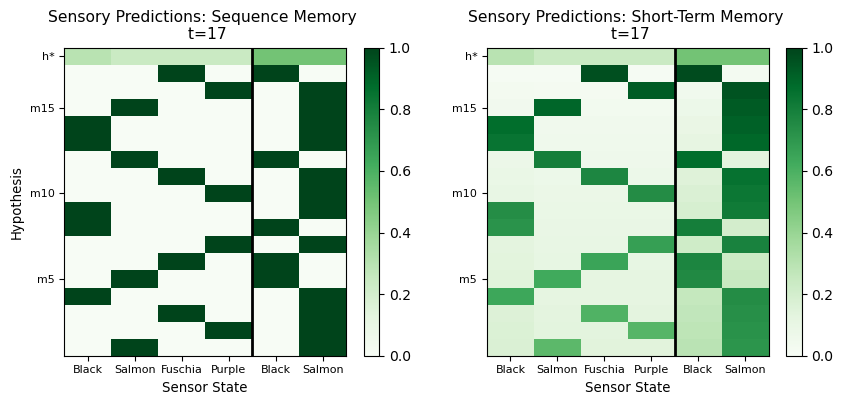

In [23]:
new_memory_capacity = num_percepts
new_memory_bias = 1/(total_situations - new_memory_capacity) #with a larger memory, we increase the memory bias

#intialize Sequence Memory
seq_memory_noisy2 = Sequence_Memory(
    new_percept_category_sizes, 
    new_memory_capacity, 
    new_memory_bias,
    new_stationary_expectations,
    stationary_transition_method = 'first',
    data_record = ['all'],
    record_until = num_percepts
)

#initialize Short-Term Memory
fading_rate = 0.05  #Controls how fast sensory predictions fade from one-hot to stationary
short_term_memory_noisy = Short_Term_Memory(
    category_sizes = new_percept_category_sizes, 
    memory_capacity = new_memory_capacity, 
    memory_bias = new_memory_bias,
    fading_rate = fading_rate,
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'first',
    data_record = ['all'],
    record_until = num_percepts
)

#Simulate
for i in range(num_percepts):
    percept = noisy_percept_sequence[i,:]
    seq_memory_noisy2.sample(percept)
    short_term_memory_noisy.sample(percept)

#Visualize Sensory Predictions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

##Sequence Memory Predictions
plot_heatmap(
    seq_memory_noisy2.sensory_predictions,
    title = "Sensory Predictions: Sequence Memory \n t=17",
    xlabel = "Sensor State",
    xtick_labels= ["Black","Salmon","Fuschia","Purple","Black","Salmon"],
    ylabel = "Hypothesis",
    yticks = [4.5,9.5,14.5,17.5],
    ytick_labels= ["m5", "m10", "m15", "h*"],
    color = "Greens",
    label_scale = 0.8,
    ax = ax1,
    category_sizes = new_percept_category_sizes)

##Short-Term Memory Predictions
plot_heatmap(
    short_term_memory_noisy.sensory_predictions,
    title = "Sensory Predictions: Short-Term Memory \n t=17",
    xlabel = "Sensor State",
    xtick_labels= ["Black","Salmon","Fuschia","Purple","Black","Salmon"],
    ylabel = None,
    yticks = [4.5,9.5,14.5,17.5],
    ytick_labels= ["m5", "m10", "m15", "h*"],
    color = "Greens",
    label_scale = 0.8,
    vmin = 0., 
    vmax = 1., #sets scale of colorbar
    ax = ax2,
    category_sizes = new_percept_category_sizes)

plt.tight_layout
pass

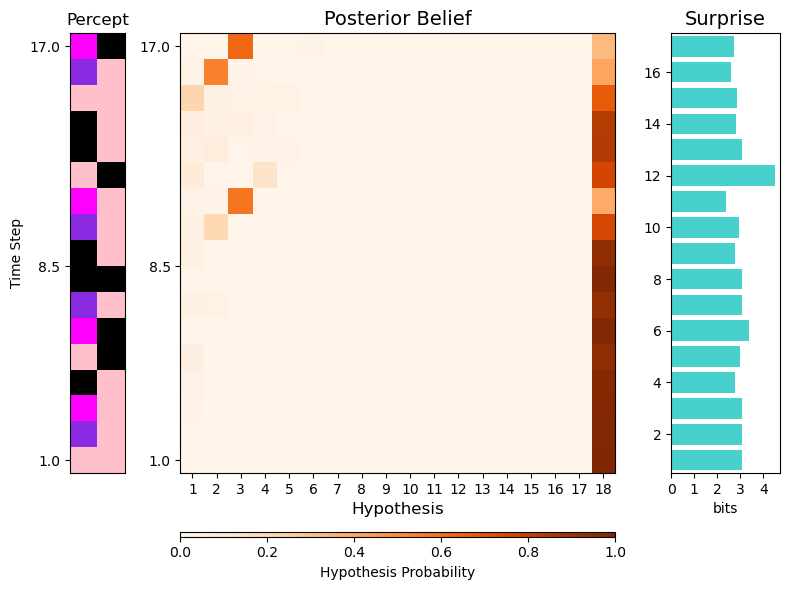

In [24]:
memory_filter_performance(short_term_memory_noisy.data_dic, noisy_percept_sequence, colormap)

We can see from these figures that when the first list repeats, the old memory traces encoding that list - though somewhat faded - still "reactivate" as evidence accumulates that the new percept sequence matches the old one. We also see some reactivation of memory traces throughout the simulation that belong to sequences that are coincidently similar - but not identical - to the first list.

## Re-evaluating the Memory Bias

In the previous simulation, we did not allow the Short-Term Memory graph to predict transitions from the stationary hypothesis to memory hypotheses other than the first, as is the default for Sequence Memory. However, as discussed in the 'Further Modelling Considerations' section of the Sequence Memory tutorial, this implicit bias makes less sense when the situations represented by memory traces provide a coarse grained model of the environmental states.

In the list_sequencer environment, for example, a previously seen list might appear after a different list or timeout interval than before. While recieving percepts from the repeated list, the memory graph's percept future is *probabilistically equivalent* to its percept future when it last saw the list - it is in the same situation. But, the percept histories of these list presentations are different. We want, then, to allow the memory graph to predict transitions from previously unexperienced situations, represented by the stationary hypothesis, to any situation represented by a memory trace. It becomes clear in this case why the memory bias is best understood as an approximation; as memories fade and yield increasingly coarse-grained representations of the situational landscape, it is impossible to know what new, unexperienced environmental states the memory trace comes to represent. This challenge is addressed to a degree by the Long-Term and Associative Memory graphs, but for now we will explore the benefits of even a roughly approximated memory bias.

Let us look at what happens when the memory_bias probability is divided across transitions to all encoded memory traces of Short-Term Memory, rather than assigned entirely to the first (or oldest) memory trace. We will first look at the transition predictions after only five time steps.

In [25]:
#Initialize new Short-Term Memory
short_term_memory_uniform_bias = Short_Term_Memory(
    category_sizes = new_percept_category_sizes, 
    memory_capacity = new_memory_capacity, 
    memory_bias = new_memory_bias,
    fading_rate = fading_rate,
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'encoded',               #changed from previous STM
    data_record = ['all'],
    record_until = num_percepts
)

#Simulate first steps
for i in range(5): #we will inspect the transition matrix after a small number of steps, then a larger number
    percept = noisy_percept_sequence[i,:]
    short_term_memory_uniform_bias.sample(percept)

#Look at transition predictions of stationary hypthesis
np.round(short_term_memory_uniform_bias.transition_predictions[-1,:], decimals = 3) #predictions of stationary hypothesis are always in last row

array([0.015, 0.015, 0.015, 0.015, 0.015, 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.923])

We can see how the memory bias is divided across encoded memory traces. After simulating up to the memory capacity, the probabilty of a transition to a memory-based hypothesis becomes divided across all traces

In [26]:
#Simulate final steps
for i in range(5,num_percepts): #we will inspect the transition matrix after a small number of steps, then a larger number
    percept = noisy_percept_sequence[i,:]
    short_term_memory_uniform_bias.sample(percept)

#Look at transition predictions of stationary hypthesis
np.round(short_term_memory_uniform_bias.transition_predictions[-1,:], decimals = 3) #predictions of stationary hypothesis are always in last row

array([0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005,
       0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.923])

Let us see, then, how this new approach changes the posterior beliefs of the Short-Term Memory graph as it observes the percepts

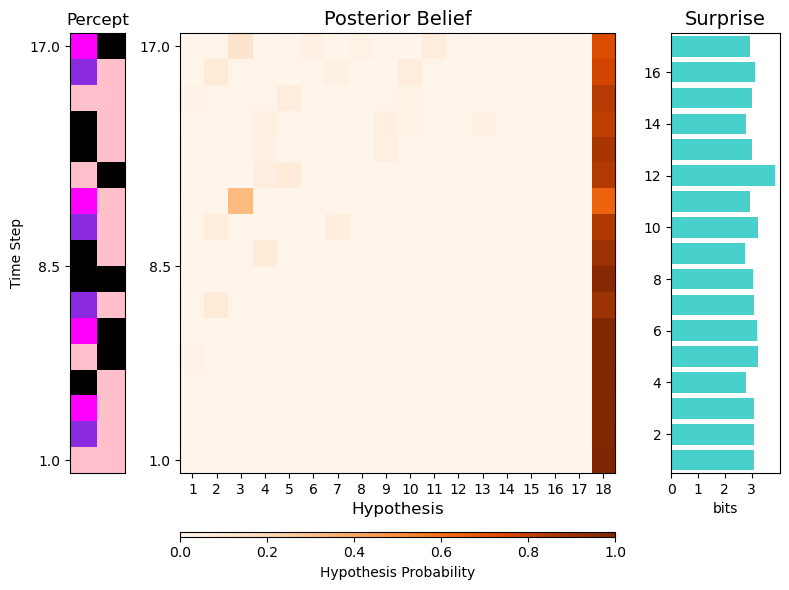

In [27]:
memory_filter_performance(short_term_memory_uniform_bias.data_dic, noisy_percept_sequence, colormap)

We can see a few things happening here. Because the probability of transitioning from the stationary hypothesis to the first memory-based hypothesis is smaller, these early memories are not as strongly reactivated by similar percept sequences. At the same time, memories of *other* lists are reactivated when *they* are similar to the most recent percept sequence. We can see (if we do some counting on the x-axis) that the final percept has reactivated both the memory trace associated with the final item of the first list and the second item of the third list - which, thanks to the noise, also has a similar history.

We are, however, using the same memory bias that was computed using the fine-grained representation assumptions of the Sequence Memory graph. Allowing that the coarser-grained representations given by the memory traces of a Short-Term memory graph may capture a greater proportion of the possible environment states, we might consider a higher value for the memory bias.

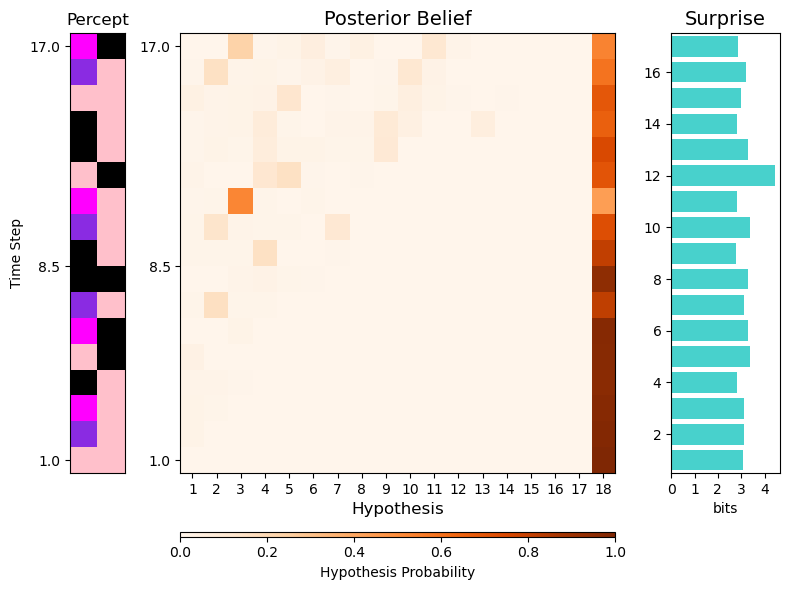

In [28]:
#Set up Short-Term Memory with bigger memory bias
bigger_memory_bias = 0.15
short_term_memory_uniform_bias2 = Short_Term_Memory(
    category_sizes = new_percept_category_sizes, 
    memory_capacity = new_memory_capacity, 
    memory_bias = bigger_memory_bias,                       #changed from previous STM
    fading_rate = fading_rate,
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'encoded',               #changed from previous STM
    data_record = ['all'],
    record_until = num_percepts
)

#Simulate
for i in range(num_percepts):
    percept = noisy_percept_sequence[i,:]
    short_term_memory_uniform_bias2.sample(percept)

memory_filter_performance(short_term_memory_uniform_bias2.data_dic,noisy_percept_sequence, colormap)

Naturally, we see higher reactivation across all memory traces. An "appropriate" memory bias is going to reflect how much memory traces fade before being re-encoded with a new percept and how large the capacity of the Short-Term Memory graph is relative the state space size of the environment it navigates. It is unlikely an embodied agent would inherit exact knowledge of such information, but even a very rough approximation can be of great use.

## The Value of Short-Term Memory

Consider an environmental state-space that produces locally similar percept patterns. A Short-Term Memory graph may use recent percept sequences to make predictions about the future. Let's look at what happens if the set of lists we have used for percept sequences so far repeats and we give the Short-Term Memory just enough capacity to remember the last percept from the first presentation of the lists.

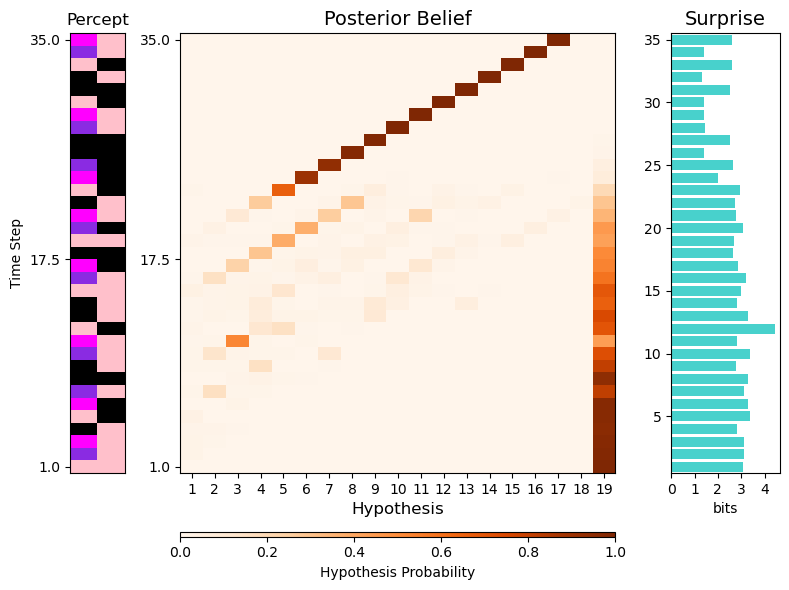

In [29]:
np.random.seed(1742031025)
#Create a repeating percept sequence, with a short timeout in between
short_timeout = np.array([0,0])[np.newaxis,:]
repeated_lists_percepts = np.concatenate((noisy_percept_sequence,short_timeout,noisy_percept_sequence), axis = 0)
#Add new noise to repeated list items and timeouts
repeated_lists_percepts[-num_percepts:,1] = np.random.choice(noisy_states,size = num_percepts)
num_percepts_repeated = 2 * num_percepts + 1 #lists presented twice, with one step timeout between

#intialize new STM
slightly_bigger_capacity = num_percepts + 1
short_term_memory_example = Short_Term_Memory(
    category_sizes = new_percept_category_sizes, 
    memory_capacity = slightly_bigger_capacity, #changed from previous STM
    memory_bias = bigger_memory_bias,
    fading_rate = fading_rate,
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'encoded',               
    data_record = ['all'],
    record_until = num_percepts_repeated #changed from previous STM
)

#Simulate
for i in range(num_percepts_repeated):
    percept = repeated_lists_percepts[i,:]
    short_term_memory_example.sample(percept)

memory_filter_performance(short_term_memory_example.data_dic, repeated_lists_percepts, colormap)


When the 'list' percept category begins to repeat, evidence increases for the hypothesis that the situation is the same as one represented by a memory trace that encodes the earlier percept. Although these faded memory traces do not make accurate predictions about the noisy percept category (see the different surprise values in later time steps), they make very good predictions about the 'list' percept category. The faded memories, on balance, make better predictions than the stationary hypothesis, and the probabilities in the posterior belief shift accordingly - yielding better predictions overall.

Thus, the use of the Short-Term Memory graph can be seen for embodied agents interacting with an environment where nearby regions of state space produce similar percept patterns. An animal that returns to a recently visited landmark could, for example, identify that landmark and make predictions about the future, despite possible changes in other features of its surroundings.

## When Short-Term Memory Fails

While the Short-Term Memory graph can identify percept sequences from its recent past that are similar to its just-recieved percept sequence to assess its situation, it can not learn about stachistic transitions between situations. In other words, the Short-Term Memory graph fails to deal appropriately with sets of (unknown) environmental states grouped together into a hypothesized situation via fading/course-graining that do *not* have probabalistically identical percept futures.

Consider what happens if the Short-Term Memory graph just simulated were to observe a new set of randomly selected lists.

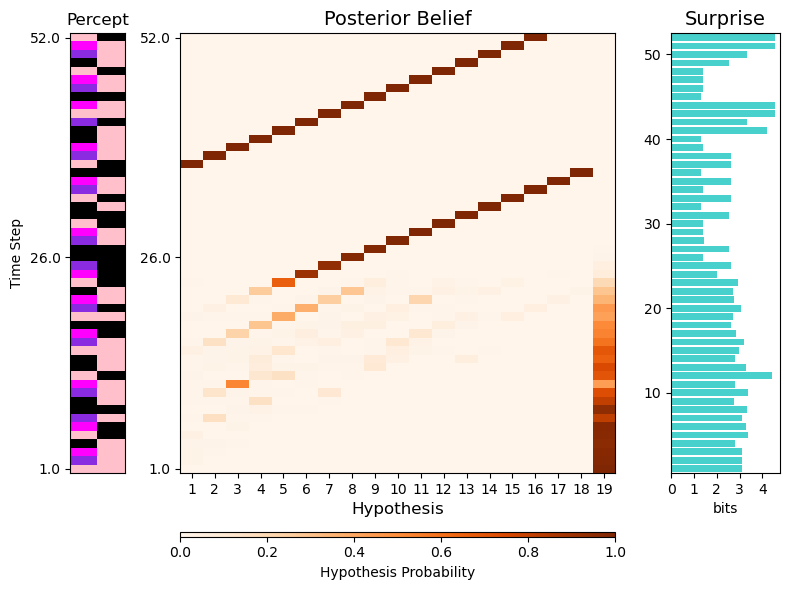

In [30]:
seed = 1430061025
#Simulate new percepts and add to previous percept sequence
new_lists = List_Sequencer(
    item_size, 
    item_category_size, 
    series_length,
    mean_timeout_interval=mean_timeout_interval,
    var_time_out_interval=var_timeout_intervel,
    num_series=num_series,
    seed = seed
    )

new_noise = np.random.choice(a=noisy_states,size=np.shape(new_lists.percept_sequence)[0])

new_percepts = np.concatenate((new_lists.percept_sequence,new_noise[:,np.newaxis]),axis = 1)

extended_percept_sequence = np.concatenate((repeated_lists_percepts, short_timeout, new_percepts), axis = 0)

num_percepts_extended = np.shape(extended_percept_sequence)[0]

#intialize new STM, same parameters as before
short_term_memory_example2 = Short_Term_Memory(
    category_sizes = new_percept_category_sizes, 
    memory_capacity = slightly_bigger_capacity,
    memory_bias = bigger_memory_bias,
    fading_rate = fading_rate,
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'encoded',               
    data_record = ['all'],
    record_until = num_percepts_extended
)

#Simulate
for i in range(num_percepts_extended):
    percept = extended_percept_sequence[i,:]
    short_term_memory_example2.sample(percept)

memory_filter_performance(short_term_memory_example2.data_dic, extended_percept_sequence, colormap)

When the first set of lists repeats, the Short Term Memory identifies this pattern and establishes a strong belief that its situation during the second presentation is the same as during the first presentation. However, this belief manifests not as a relation between memory traces of the two events, but as the reactivation of the cycle-length-old memory trace each time step. When the 'locally repeated pattern' ends, and lists become random again, the Short-Term Memory continues to look back the same distance in time to make predictions. These predictions are no longer effective, as evidenced by the increased surprise. Unfortunately, the memory graph has already established a strong belief in its situation, and it has a strict implicit bias that all percept futures of a given situation are probabilistically equivalent. It will require a great deal of evidence to disuade its establised belief state, and nothing "true" about the environment has been learned - the repeated lists have already been forgotten (via overwriting of memory traces) by the end of the simulation.

How, then, can a memory graph learn about the transitions of unknown environmental states that have been included - via the World Model coarse-graining introduced by memory fading - in its memory-based hypotheses about its situation?

# Long-Term Memory

The first step in learning about unknown environment states included in a memory-based, situational hypothesis is to arrest the fading of useful memories such that the set of states they represent stops changing. A Long-Term Memory graph does this in two ways: it (1) modulates the initial fading rate of each percept category in a memory trace according to how suprising the state of that percept category was at the time and (2) reduces the fading rate, at each time step, of all percept states encoded to each memory trace as a function of that memory trace's re-activation (the probability it is assigned in the posterior belief).

## Suprise-Mediated Memory Fading

In Long-Term Memory there is no single fading rate. Instead, each percept category of each memory trace fades at its own rate. For this memory graph, the *fading_rate* parameter is used as a baseline. When a new memory is encoded, if the surprise of the observed state of a percept category is the same as if a prediction had been made conditioned entirely on the stationary hypothesis, then the fading rate of that percept category is intially set to the *fading_rate* parameter. If the state of the percept category is more suprising, then the intial fading rate for that percept category will be lower than the *fading_rate* parameter. This might happen, for example, if the prior belief was weighted to some degree on a memory trace that strongly predicted a percept category state that was not observed. Conversely, if the state of percept category is less surprising - according the prior belief - than it would be according to the stationary hypothesis, then the initial fading rade of that category in the encoded memory will be greater than the *fading_rate* parameter. 

How much slower or faster the fading rate of a newly encoded perecept category is in memory depends on how much more or less suprising the state was relative the the stationary prediction (henceforth the 'surprise difference') and on the *surprise_factor* parameter. The *surprise_factor* parameter scales a sigmoid function that defines this relationship. If *suprise_factor* is zero, the sigmoid reduces to a flat line, and all initial fading rates equal the fading_rate paramter, regardless of surprise difference. As *surprise_factor* approaches one, a positive surprise difference (belief prediction more suprising than stationary) will push the fading rate of the category toward $0$ faster. Likewise, a negative surprise difference will push the fading rate of the category toward $1$$ faster.

The idea here is that surprise is, by definition, the amount of new information gained by the observation of that particular percept category state. If the surprise difference is negative, it means the memory graph has allowed a better prediction than the stationary hypothesis alone. Thus, relevant information has likely been learned already and the state of the enviornment at the current time may already be included in the situation represented by a previous memory-based hypothesis (as a result of fading-induced coarse-graining). The newly encoded percept category can, and should, in this case be forgetten if the hypothesis space is to remain exhaustive and mutually exlusive.

Let us see how this looks in practice. Consider a Long-Term memory graph that recieves the same repeated list of sequences used to illustrate the value of Short-Term Memory.

In [31]:
from projective_simulation.ECMs. state_estimators import Long_Term_Memory

In [32]:
#Set up Long-Term Memory paramters
high_suprise_factor = 0.99
no_memory_consolidation = 0 #amounts to turning off memory consolidation, which we explore in the next section
bigger_capacity = np.shape(repeated_lists_percepts)[0] #To see the effects of surprise mediation, we want to compare memory traces from both presentations of the repeated list sequence

#initialize LTM
surprise_mediation_LTM = Long_Term_Memory(
    category_sizes= new_percept_category_sizes,
    memory_capacity= bigger_capacity,           #changed from previous STM example
    memory_bias = bigger_memory_bias,
    fading_rate = fading_rate,
    surprise_factor=high_suprise_factor,        #new
    consolidation_rate=no_memory_consolidation, #new parameter, but with value implicit in STM graph
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'encoded',               
    data_record = ['all'],
    record_until = bigger_capacity              #changed from previous STM example
)

#initialize STM with larger capacity for comparison
short_term_memory_comparison = Short_Term_Memory(
    category_sizes = new_percept_category_sizes, 
    memory_capacity = bigger_capacity, #changed from previous STM
    memory_bias = bigger_memory_bias,
    fading_rate = fading_rate,
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'encoded',               
    data_record = ['all'],
    record_until = bigger_capacity #changed from previous STM
)


#Simulate
for i in range(num_percepts_repeated):
    percept = repeated_lists_percepts[i,:]
    surprise_mediation_LTM.sample(percept)
    short_term_memory_comparison.sample(percept)

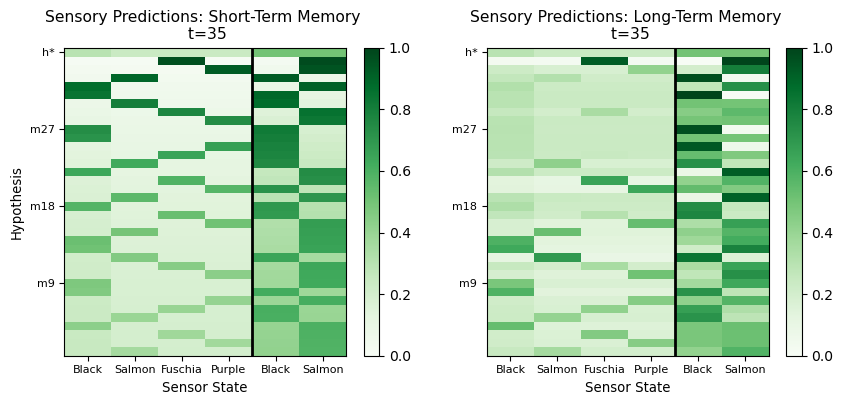

In [33]:
#Visualize sensory predictions of STM and LTM side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

##Short-Term Memory Predictions
plot_heatmap(
    short_term_memory_comparison.sensory_predictions,
    title = "Sensory Predictions: Short-Term Memory \n t=35",
    xlabel = "Sensor State",
    xtick_labels= ["Black","Salmon","Fuschia","Purple","Black","Salmon"],
    ylabel = "Hypothesis",
    yticks = [8.5,17.5,26.5,35.5],
    ytick_labels= ["m9", "m18", "m27", "h*"],
    color = "Greens",
    label_scale = 0.8,
    vmin = 0., 
    vmax = 1., #sets scale of colorbar
    ax = ax1,
    category_sizes = new_percept_category_sizes)

#Long-Term Memory Predictions
plot_heatmap(
    surprise_mediation_LTM.sensory_predictions,
    title = "Sensory Predictions: Long-Term Memory \n t=35",
    xlabel = "Sensor State",
    xtick_labels= ["Black","Salmon","Fuschia","Purple","Black","Salmon"],
    ylabel = None,
    yticks = [8.5,17.5,26.5,35.5],
    ytick_labels= ["m9", "m18", "m27", "h*"],
    color = "Greens",
    label_scale = 0.8,
    vmin = 0., 
    vmax = 1., #sets scale of colorbar
    ax = ax2,
    category_sizes = new_percept_category_sizes)

plt.tight_layout
pass

We can see that the sensory predictions for list items encoded by memory traces from the second presentation of the list sequence have rapidly faded toward the stationary distribution. This is because the posterior belief quickly converges on the memory traces of the previously observed list sequence, allowing accurate predictions for this percept category. Accurate prediction means low surprise, which means a high initial fading rate. The noisy percept category, on the other hand, is sometimes more suprising, leading to slower fading rates for the noisy category in these memories. This is because, as the belief state converges onto a single memory trace, it predicts that the noisy percept category will also match this memory - but this is only true 50% of the time. We can see the surprise of the two different categorie directly by passing "True" to the optional *stacked* argument of the memory_filter_performance function, and setting the *bar_colors* argument.

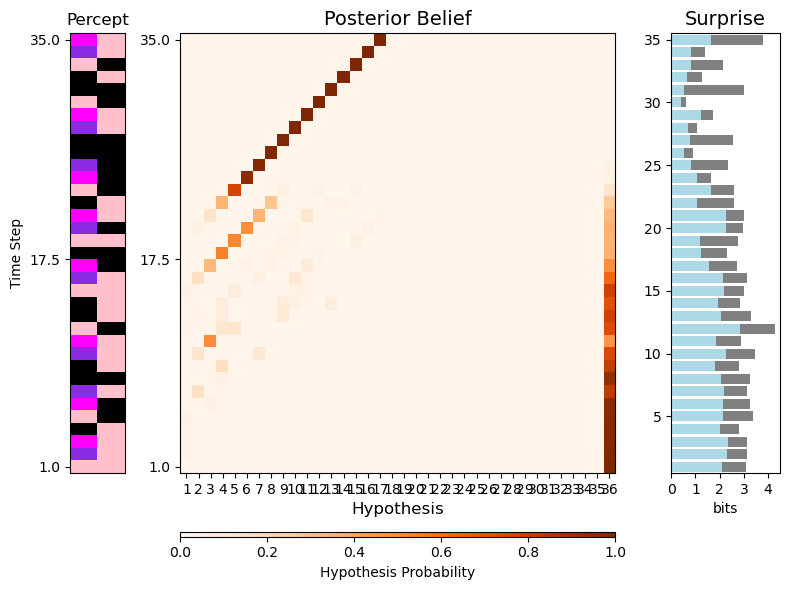

In [34]:
memory_filter_performance(surprise_mediation_LTM.data_dic, repeated_lists_percepts, colormap,stacked = True, bar_colors = ["lightblue", "grey"]) #grey is the surprise contribution of the noisy sensory

## Memory Trace Consolidation

The second function of long term memory is to stablize the sensory predictions of memory-based hypotheses that are frequently re-activated by slowing the fading rate of all encoded percept categories. Each time step, the fading rate of all encoded percepts categories in a Long-Term Memory graph are multiplied by the product of the associated memory-traces probability in the posterior belief and $1 -$ the *consolodation_rate* parameter. This means that if the posterior probability of a memory-based hypothesis is $1$ (this can't happen, but it can become arbitrarily close) and the consolodation rate is also $1$, the fading rate of all percept categories encoded in that memory trace will immediately be set to $0$.

Let us examine how this changes the behavior of the Long-Term Memory graph in the example above.

In [35]:
#Set up Long-Term Memory paramters
high_suprise_factor = 0.99
high_memory_consolidation = 0.9

#initialize LTM
consolodation_LTM = Long_Term_Memory(
    category_sizes= new_percept_category_sizes,
    memory_capacity= bigger_capacity,           
    memory_bias = bigger_memory_bias,
    fading_rate = fading_rate,
    surprise_factor=high_suprise_factor,        
    consolidation_rate=high_memory_consolidation, #changed from previous
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'encoded',               
    data_record = ['all'],
    record_until = bigger_capacity
)

#Simulate
for i in range(num_percepts_repeated):
    percept = repeated_lists_percepts[i,:]
    consolodation_LTM.sample(percept)

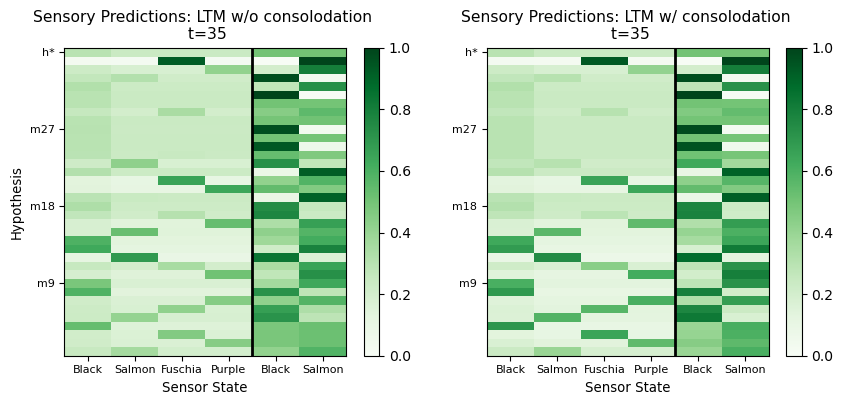

In [36]:
#Visualize sensory predictions of LTM with and without memory consolodation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

#Long-Term Memory Predictions
plot_heatmap(
    surprise_mediation_LTM.sensory_predictions,
    title = "Sensory Predictions: LTM w/o consolodation \n t=35",
    xlabel = "Sensor State",
    xtick_labels= ["Black","Salmon","Fuschia","Purple","Black","Salmon"],
    ylabel = "Hypothesis",
    yticks = [8.5,17.5,26.5,35.5],
    ytick_labels= ["m9", "m18", "m27", "h*"],
    color = "Greens",
    label_scale = 0.8,
    vmin = 0., 
    vmax = 1., #sets scale of colorbar
    ax = ax1,
    category_sizes = new_percept_category_sizes)

#Long-Term Memory Predictions
plot_heatmap(
    consolodation_LTM.sensory_predictions,
    title = "Sensory Predictions: LTM w/ consolodation \n t=35",
    xlabel = "Sensor State",
    xtick_labels= ["Black","Salmon","Fuschia","Purple","Black","Salmon"],
    ylabel = None,
    yticks = [8.5,17.5,26.5,35.5],
    ytick_labels= ["m9", "m18", "m27", "h*"],
    color = "Greens",
    label_scale = 0.8,
    vmin = 0., 
    vmax = 1., #sets scale of colorbar
    ax = ax2,
    category_sizes = new_percept_category_sizes)

plt.tight_layout
pass

Note that the early memory traces, which are re-activated upon the re-presentation of the list sequence, are less faded in the LTM graph with memory consolodation.

## The Value of Long-Term Memory

The Long-Term Memory graph prioritizes the retention of information that is not already predictable from existing situational hypotheses. This is important because if a real situation in the environmental state space becomes encoded by two different memory traces, then the assumption that the hypothesis space is mutually exclusive becomes violated. To some extent, this problem is unnavoidable - the memory graph is by design not given enough information to disentangle these situations at first - but the goal is to mitigate the problem as much as possible.

Let us compare Long-Term and Short-Term Memory graphs in the case where random list sequencing resumes after the re-presentation of the first list sequence.

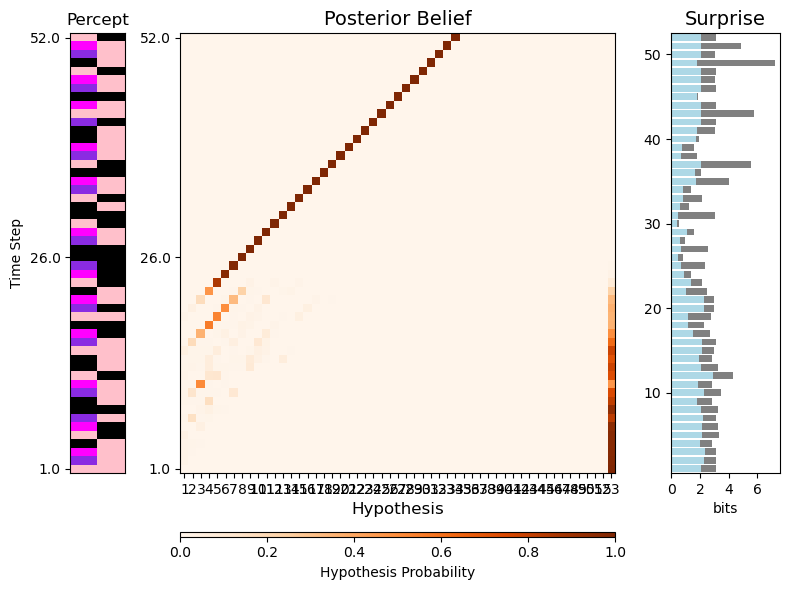

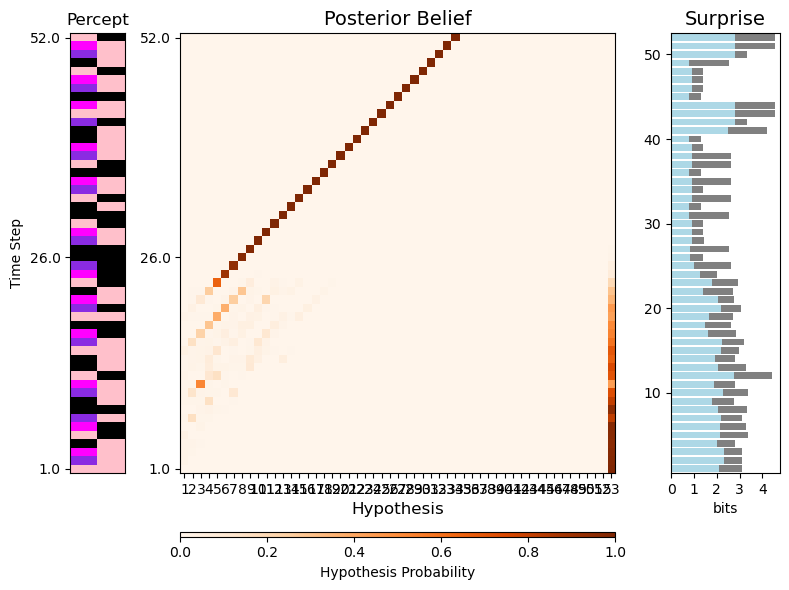

In [37]:
even_bigger_capacity = np.shape(extended_percept_sequence)[0] #We will give both LTM and STM enough capacity to remember all percepts in the sequence

#intialize new STM, same parameters as before
high_capacity_STM = Short_Term_Memory(
    category_sizes = new_percept_category_sizes, 
    memory_capacity = even_bigger_capacity,      #changed from previous STM example
    memory_bias = bigger_memory_bias,
    fading_rate = fading_rate,
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'encoded',               
    data_record = ['all'],
    record_until = even_bigger_capacity          #changed from previous STM example
)

#initialize LTM
high_capacity_LTM = Long_Term_Memory(
    category_sizes= new_percept_category_sizes,
    memory_capacity= even_bigger_capacity,       #changed from previous LTM example    
    memory_bias = bigger_memory_bias,
    fading_rate = fading_rate,
    surprise_factor=high_suprise_factor,        
    consolidation_rate=high_memory_consolidation, 
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'encoded',               
    data_record = ['all'],
    record_until = even_bigger_capacity         #changed from previous LTM example
)

#Simulate
for i in range(num_percepts_extended):
    percept = extended_percept_sequence[i,:]
    high_capacity_LTM.sample(percept)
    high_capacity_STM.sample(percept)

memory_filter_performance(high_capacity_LTM.data_dic, extended_percept_sequence, colormap,stacked = True, bar_colors = ["lightblue", "grey"])
memory_filter_performance(high_capacity_STM.data_dic, extended_percept_sequence, colormap,stacked = True, bar_colors = ["lightblue", "grey"])


The posterior beliefs for the STM graph and the LTM graph look similar throughout the simulation, but the surprisals look different (mind the difference in scale). This arises from differences in the sensory predictions, visualized below. The LTM graph retains earlier memories more clearly, yielding stronger prediction and less surprise when the first sequence of lists repeats. Memories of this second sequence therefore fade rapidly. It is these highly faded memory traces that are then used to make predictions when lists presented are again randomized, yielding surprise that is similar to if predictions had been made using the stationary hypothesis.

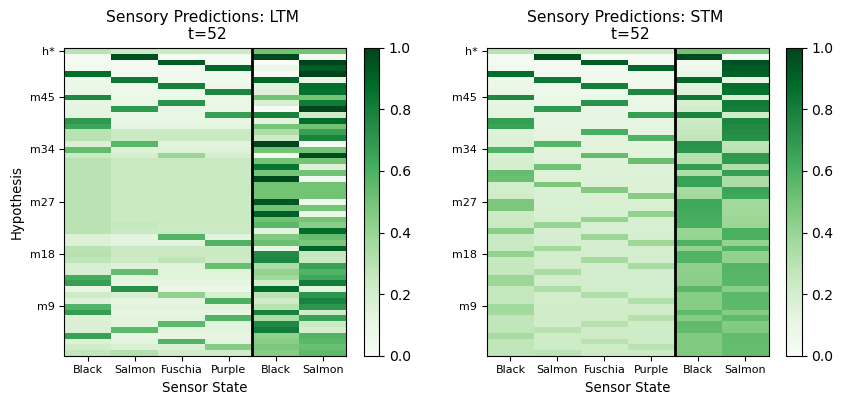

In [38]:
#Visualize sensory predictions of LTM with and without memory consolodation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

#Long-Term Memory Predictions
plot_heatmap(
    high_capacity_LTM.sensory_predictions,
    title = "Sensory Predictions: LTM \n t=52",
    xlabel = "Sensor State",
    xtick_labels= ["Black","Salmon","Fuschia","Purple","Black","Salmon"],
    ylabel = "Hypothesis",
    yticks = [8.5,17.5,26.5,35.5,44.5,52.5],
    ytick_labels= ["m9", "m18", "m27", "m34","m45", "h*"],
    color = "Greens",
    label_scale = 0.8,
    vmin = 0., 
    vmax = 1., #sets scale of colorbar
    ax = ax1,
    category_sizes = new_percept_category_sizes)

#Long-Term Memory Predictions
plot_heatmap(
    high_capacity_STM.sensory_predictions,
    title = "Sensory Predictions: STM \n t=52",
    xlabel = "Sensor State",
    xtick_labels= ["Black","Salmon","Fuschia","Purple","Black","Salmon"],
    ylabel = None,
    yticks = [8.5,17.5,26.5,35.5,44.5,52.5],
    ytick_labels= ["m9", "m18", "m27", "m34","m45", "h*"],
    color = "Greens",
    label_scale = 0.8,
    vmin = 0., 
    vmax = 1., #sets scale of colorbar
    ax = ax2,
    category_sizes = new_percept_category_sizes)

plt.tight_layout
pass

It is clear the features of Long-Term Memory alone do not help to learn about stochastic transitions between situation. But, they are a step toward two useful processess. 

The first process concerns which memory traces are overwritten when the memory graph has reached capacity. Long-Term Memory graphs can not simply overwrite the oldest memory trace as Short-Term Memory graphs do - that would defeat the purpose of surprise-mediated retention and consolidation. Instead, the *most faded* traces may be overwritten (which notably could be implemented for Short Term Memory as well without changing its behavior). This is not as straight-forward as it immediately seems however. One must consider how transition predictions of memory traces that point to the overwritten trace are updated. Additionally, even memory traces with completely faded sensory encodings may still carry information about the time-intervals that seperate situation-differentiating percepts. Methods to exploit the properties of Long-Term Memory graphs for the efficient re-writing of memory traces are therefore still in development.

The second process afforded by the properties of the Long-Term Memory graph is experience-driven plasticity in memory-based hypothesis predictions. This becomes possible because consolodated memories may be reactivated indefinitely through time - provided sufficient capacity or a effecient trace rewriting scheme as just described. Consider what happens if, instead of presenting a random sequence of lists the initial sequence of lists is presented for a third time.

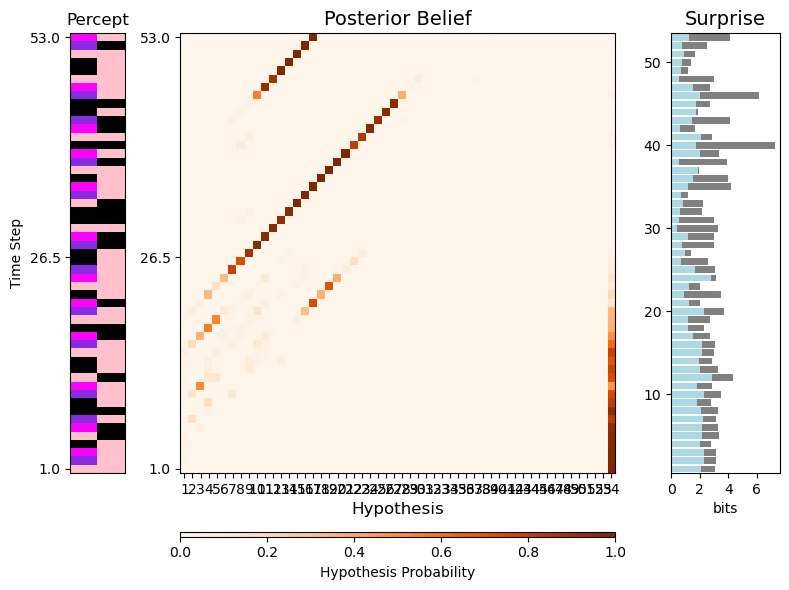

In [39]:
np.random.seed(1522071025)
#Set up Percept Sequence
thrice_repeated_lists_percepts = np.concatenate((repeated_lists_percepts, short_timeout, noisy_percept_sequence), axis = 0)
new_noise = np.random.choice(a=noisy_states,size = np.shape(repeated_lists_percepts)[0])[:,np.newaxis]
thrice_repeated_lists_percepts[-np.shape(new_noise)[0]:,1:] = new_noise #overwite noisy percept states with new noise for third presentation of list sequence
num_percepts_thrice_repeated = np.shape(thrice_repeated_lists_percepts)[0]

#Set up LTM
thrice_repeated_LTM = Long_Term_Memory(
    category_sizes= new_percept_category_sizes,
    memory_capacity= num_percepts_thrice_repeated,       #changed from previous LTM example    
    memory_bias = bigger_memory_bias,
    fading_rate = fading_rate,
    surprise_factor=high_suprise_factor,        
    consolidation_rate=high_memory_consolidation, 
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'encoded',               
    data_record = ['all'],
    record_until = num_percepts_thrice_repeated         #changed from previous LTM example
)

#simulate
for i in range(num_percepts_thrice_repeated):
    percept = thrice_repeated_lists_percepts[i,:]
    thrice_repeated_LTM.sample(percept)

memory_filter_performance(thrice_repeated_LTM.data_dic, thrice_repeated_lists_percepts, colormap,stacked = True, bar_colors = ["lightblue", "grey"])

Notice that the beleif state in the later time steps breaks from the forward transitions predicted by the memory traces. Why is this?

When the same sequence of lists is presented for a third time, the Long-Term Memory graph has two sets of memory traces to draw on: the sharp memory traces from the first presentation of the list sequence and the faded memory from the second presentation of the list sequence. For the first percepts presented during the third list sequence, the posterior belief assigns high probability to traces from the second list sequence. This is because a belief was established during the second presentation of the sequence that the situation was very likely the same as during the first sequence and these first memory traces predict a subsequent transition to the second memory traces. These second memory are faded, however, so over time the sharper - and thus more predictive - memory traces from the first sequence presentation become reactivated.

By allowing redundant information to fade and only retaining memories that encode new information, Long-Term Memory graphs are more likely to re-activate the same trace each time a situation - or a sequence of percepts that might belong to that situation - repeats. It is through these repeated re-activations that the memory graph may be able to learn about the true situation in its environment that its memory trace has come to represent.

The other advantage of Long-Term Memory is that the envrionmental states in a situation need not necesarily be nearby in state-space to be effectively represented by the memory graph. Whereas the memory traces of a Short Term Memory Graph will fade in the time between the observation of these states - regardless of capacity - the Long-Term Memory will retain and use that information - provided it has large enough capacity. We do not simulate such a scenario here, but invite the reader to examine the belief states of high capacity LTM and STM graphs observing a long List_Sequencer percept as an exercise.

## Where Long-Term Memory Fails

We have already noted in the previous section that the features of Long-Term Memory are not *per se* sufficient to learn about stochastic transitions between situations. For this, we turn to the Associative Memory graph.

# Associative Memory

When we say that the Long-Term Memory graph cannot learn about stochastic transition between situations, what do we really mean? Up to this point, we have allowed - by definition - environmental states with different perceptual pasts to be included in the same situation, but required those states to have probabilitically equivalent perceptual futures. What is a memory graph to do, however, if some environmental states have probabilistically equivalent perceptual pasts but different perceptual futures? A memory graph with an implicit bias that memory-based hypotheses deterministically predict a transition to the subsequently encoded memory-based hypothesis simply cannot represent such a scenario. Instead, we must relax our definition of a situation to include the set of environmental states that have probabalistically equivalent perceptual futures *or* probabilitically equivalent perceptual pasts - but share a probabalistically equivalent perceptual *present*. If a memory graph is to represent such a situation effectively, we must then find a way for it to determine whether new information (from surprising percepts) should be used to update the predictions existing memory-based hypotheses or as the basis of a new memory-based hypothesis. The Associative Memory Graph takes a step in this direction by allowing both, with parameters to scale the **plasticity** of existing memory traces.

The associative Memory graph introduces memory trace plasticity in two forms. **Memory trace re-encoding** updates the sensory predictions of a re-activated memory trace as a function of the current percept. **Memory trace re-association** updates the transition predictions of a re-activated memory as a function of the difference between the currently encoded transtion predictions and the posterior probability that such a transition occured given the next percept.

## Memory Trace Re-encoding

Memory trace re-encoding describes the plasticity of *sensory predictions* when a memory trace is re-activating. The degree of this plasticity is given by a new parameter, *reencoding_rate*, which can take values between $0$ and $1$. Each time step, after sensory predictions have faded, the sensory predictions of each memory trace are mixed with the one-hot encoding of the current percept. The weight of the current percept in this mixture is the re-activation strength of the memory (its porbability in the posterior belief) times the re-encoding rate. Thus, if the posterior probability that a given memory-based hypothesis represents the current situation and the re-encoding rate are both $1$ then the sensory predictions of the memory trace will be completely overwritten by the current percept. Naturally, intermediate values are called for.

Let us examine how memory trace re-encoding affects the behavior of an Associative Memory Graph that observes the same initial list sequence used for example thus far.

In [40]:
from projective_simulation.ECMs.state_estimators import Associative_Memory

In [ ]:
#Set Up Associative Memory
no_consolidation = 0 #some effects of re-encoding look like consolidation. We remove memory consolidation to show these effects are actually the result of re-encoding
high_reencoding_rate = 0.8
no_reassociation = 0 #this will be introduced next

num_percepts = np.shape(noisy_percept_sequence)[0]     #already defined, here as a reminder

reencoding_AM = Associative_Memory(
    category_sizes= new_percept_category_sizes,
    memory_capacity= num_percepts,                      #changed from previous LTM example    
    memory_bias = bigger_memory_bias,
    fading_rate = fading_rate,
    surprise_factor = high_suprise_factor,        
    consolidation_rate = no_consolidation,               #changed from previous LTM example
    reencoding_rate = high_reencoding_rate,               #new parameter
    reassociation_rate = no_reassociation,                #new parameter, value given is implicit in LTM
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'encoded',     
    data_record = ['all'],
    record_until = num_percepts                         #changed from previous LTM example
)

#Set up of LTM for comparison.
no_consolidation_LTM = Long_Term_Memory(
    category_sizes= new_percept_category_sizes,
    memory_capacity= num_percepts,                      #changed from previous LTM example    
    memory_bias = bigger_memory_bias,
    fading_rate = fading_rate,
    surprise_factor=high_suprise_factor,        
    consolidation_rate= no_consolidation,               #changed from previous LTM example
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'encoded',               
    data_record = ['all'],
    record_until = num_percepts                         #changed from previous LTM example
)

#Simulate
for i in range(num_percepts):
    percept = noisy_percept_sequence[i,:]
    reencoding_AM.sample(percept)
    no_consolidation_LTM.sample(percept)

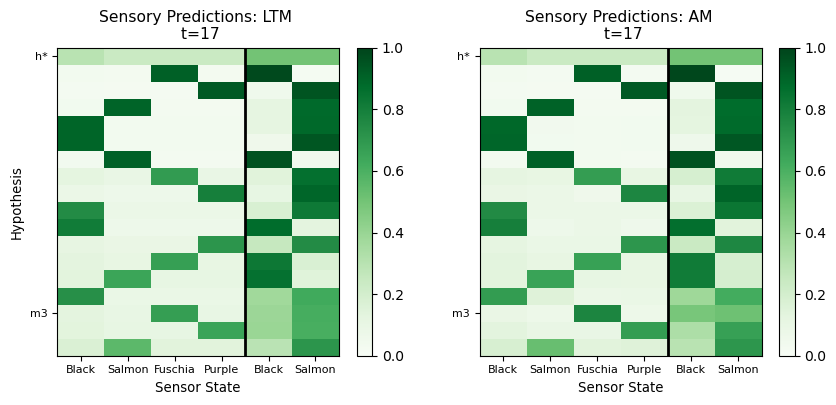

In [ ]:
#Visualize sensory predictions of LTM with and without memory consolodation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

#Long-Term Memory Predictions
plot_heatmap(
    no_consolidation_LTM.sensory_predictions,
    title = "Sensory Predictions: LTM \n t=17",
    xlabel = "Sensor State",
    xtick_labels= ["Black","Salmon","Fuschia","Purple","Black","Salmon"],
    ylabel = "Hypothesis",
    yticks = [2.5,17.5],
    ytick_labels= ["m3", "h*"],
    color = "Greens",
    label_scale = 0.8,
    vmin = 0., 
    vmax = 1., #sets scale of colorbar
    ax = ax1,
    category_sizes = new_percept_category_sizes)

#Associative Memory Predictions
plot_heatmap(
    reencoding_AM.sensory_predictions,
    title = "Sensory Predictions: AM \n t=17",
    xlabel = "Sensor State",
    xtick_labels= ["Black","Salmon","Fuschia","Purple","Black","Salmon"],
    ylabel = None,
    yticks = [2.5,17.5],
    ytick_labels= ["m3", "h*"],
    color = "Greens",
    label_scale = 0.8,
    vmin = 0., 
    vmax = 1., #sets scale of colorbar
    ax = ax2,
    category_sizes = new_percept_category_sizes)

plt.tight_layout
pass

The difference between these two memory graphs is subtle, but look at the sensory predictions of the third memory-based hypothesis. In the associative memory, this trace is sharper in the list item category than the LTM, but more washed-out in the noisy category. What is happening here? You may recall from the Sequence Memory tutorial that the memory trace for the third item in the first list is reactivated multiple times - once when the last list turns out to be the same, and once when the noisy category during the third list results in a similar percept sequence. The same is true for the Associateive Memory, depicted below (and the LTM, not depicted). For the Associative Memory Graph, however, the re-activation also entails re-encoding. Because the list item percept matches the old memory trace, this serves to counter-act some of the fading that has occured. The noisy category is different in the final reactivation, however, so sensory predictions in this category get washed out. 

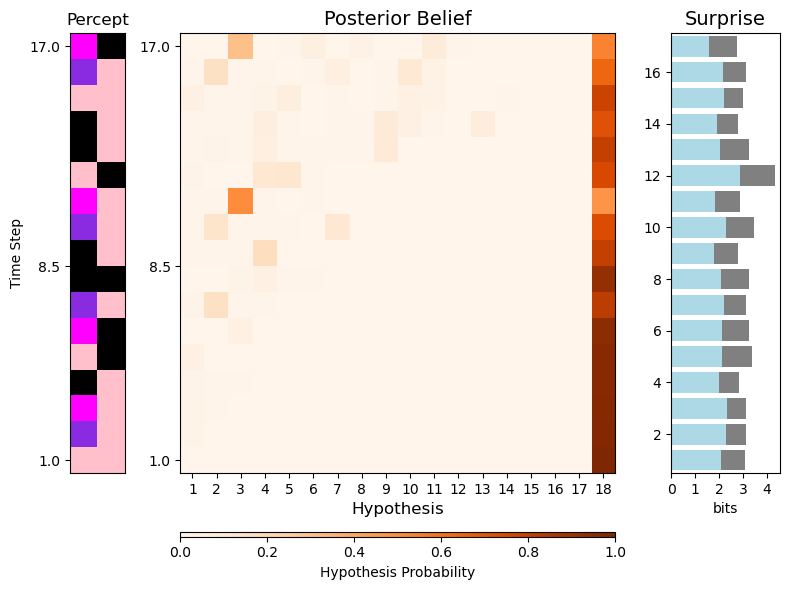

In [43]:
memory_filter_performance(reencoding_AM.data_dic, noisy_percept_sequence,colormap,stacked=True, bar_colors=['lightblue', 'grey'])

## Memory Trace Re-Association

### The Mechanics

Memory trace re-association refers to the plasticity of transition predictions upon memory trace activation. The mathematics of this update are somewhat more complicated. Here is how it works.

We first need to consider the **prior probability of an hypothesis transition**. This prior probability at some time $t$ is given by the posterior probability of some hypothesis $i$ at time $t-1$ times the probability encoded in hypothesis $i$ of transitioning to some hypothesis $j$. This value defines the probability, according the the memory graph's beliefs, that hypothesis $i$ was true at $t-1$ and hypothesis $j$ is true at time $t$, before seeing the percept at time $t$. The **posterior probability of an hypothesis transition** is given by the posterior probability of hypothesis $i$ at $t-1$ (same term as before) times *the posterior probability of hypothesis $j$ at time $t$*.

During memory trace re-association, the prior probability of each hypothesis transition is subtracted from the posterior probability of that hypothesis transition. This difference is multiplied by the *reassociation_rate* parameter and then added to the transition predictions of hypothesis $i$.

To understand the result of this update, consider a memory graph that believed at time $t-1$ that there was a 50% chance hypothesis $i$ was true and hypothesis $i$ predicted a 100% probability of transitioning to hypothesis $j$. After observing the percept at time $t$, the memory graph believes there 50% chance that hypothesis $j$ is true. The posterior probability of that hypothesis transition ($0.5 * 0.5$) is 25% less than the prior probability ($0.5 * 1.0$). This seems wrong! What is going on? 

Consider another hypothesis $i'$, which the memory graph also believed there was a 50% chance was true at time $t-1$ and which predicted a 100% probabilty of transitioning to some fourth hypothesis $j'$. The posterior probaility of $j'$, like that of $j$, is 50% at time $t$. The posterior probability of a transition from $i$ to $j'$ is then also $0.5 * 0.5$. Likewise for the transition from $i'$ to $j$. Thus, if the re-encoding rate is $1$, the new transition probabilities from $i$ to $j$ and $i'$ to $j'$ will be 75% while the new transition probabilties from $i$ to $j'$ and $i'$ to $j$ will be 25%. 

When the re-association rate is high, transition predictions are shaped more strongly by new possibilities and less beholden to initially encoded percept sequences. Again, intermediate values are generally called for. 

Let us examine the result of adding memory trace reassociation to the Associative Memory defined in the Memory Trace Re-encoding example. We will look first at the behavior of the posterior belief.

In [72]:
high_reassociation_rate = 0.5
reassociation_AM = Associative_Memory(
    category_sizes= new_percept_category_sizes,
    memory_capacity= num_percepts,                         
    memory_bias = bigger_memory_bias,
    fading_rate = fading_rate,
    surprise_factor = high_suprise_factor,        
    consolidation_rate = no_consolidation,                
    reencoding_rate = high_reencoding_rate,               
    reassociation_rate = high_reassociation_rate,              #changed from previous AM example
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'learned',                  #changed from previous AM example, see next section on memory bias
    data_record = ['all'],
    record_until = num_percepts
)
#Simulate
stationary_transition_data = np.full((num_percepts,np.shape(reassociation_AM.transition_predictions)[1]), -1.) #to record transition predictions of stationary hypothesis at each time step 
for i in range(num_percepts):
    percept = noisy_percept_sequence[i,:]
    reassociation_AM.sample(percept)
    stationary_transition_data[i,:] = reassociation_AM.transition_predictions[-1,:] #Looking at the evolution of these predictions will be helpful to understand reassociation and memory_bias

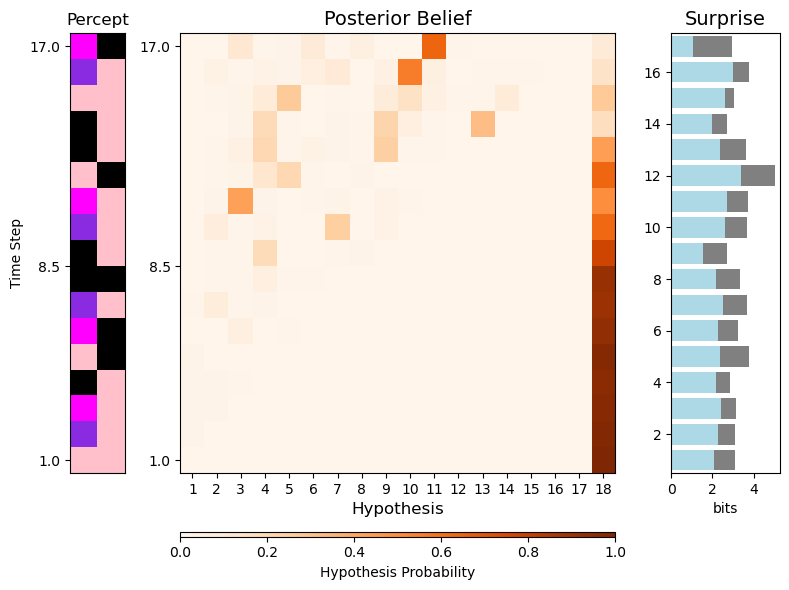

In [78]:
memory_filter_performance(reassociation_AM.data_dic, noisy_percept_sequence,colormap, stacked = True, bar_colors = ['lightblue', 'grey'])

This looks quite different from the previous example without memory trace re-association! What is going on? The first thing we need to consider is how memory trace re-association interacts with the transition predictions (and therfore with the memory bias).

### Re-evaluating Memory Bias (Again)

Because transitions to and from the stationary hypothesis are involved in updating transtions to and from memory-based hypotheses, they become updated in memory trace re-association in exactly the same manner. This means the memory bias can not be neatly divided across encoded memories. Instead, when a new memory is encoded, the transition from the stationary hypothesis to the new memory is assigned a weight equal to *memory_bias*. Then, transition predictions from the stationary hypothesis are renormalized.

This methodology is adopted by setting the default *stationary_transition_method* for Associative Memory to "learned". If this argument is overwritten (as in the re-encoding example), no memory trace re-association will occur! If, in such a case, the re-association rate is greater than $0$, any attempt to update the transition weight, such as when sample() is called, will return a warning.

If both the re-association rate and the memory bias are high, the effect can be quite dramatic. Take a look at the transition predictions after the first and the second percept, which we recorded when we ran the simulation

In [74]:
np.round(stationary_transition_data[0:2,:], decimals = 3)

array([[0.14 , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.86 ],
       [0.067, 0.13 , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.802]])

Because of the renormalization, the initial transition probability given to a newly encoded memory trace by the stationary hypothesis is a bit lower than the actual memory bias. But after a single time step, that probability has fallen dramatically. This is because the posterior probability of the stationary hypothesis at $t=1$ was very high and the posterior probability of the first memory-based hypothesis at t=2 was very low (the percept's don't match). With a high re-association rate, the failture to see the predicted transtion strongly outweighs the existing prediction. The effect is that an associative memory graph with high memory bias will strongly predict transitions from the stationary hypothesis to more recently encoded memory-based hypotheses, or to those memory-based hypotheses which have had very little re-activation subsequent to posterior belief in the stationary hypothesis. Take a look at the transition predictions at the end of the simulation for the Associative Memory graphs with and without re-association.

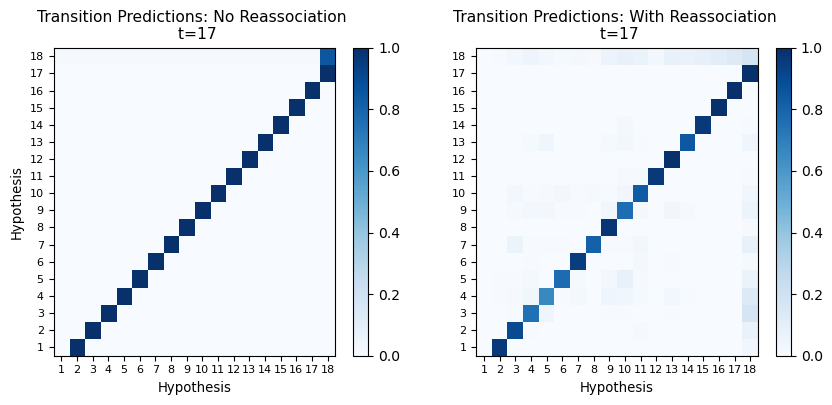

In [45]:
#Visualize transition predictions of LTM with and without memory consolodation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

#No reassociation transitions
plot_heatmap(
    reencoding_AM.transition_predictions,
    title = "Transition Predictions: No Reassociation \n t=17",
    xlabel = "Hypothesis",
    ylabel = "Hypothesis",
    color = "Blues",
    label_scale = 0.8,
    vmin = 0., 
    vmax = 1., #sets scale of colorbar
    ax = ax1
    )

#Associative Memory Predictions
plot_heatmap(
    reassociation_AM.transition_predictions,
    title = "Transition Predictions: With Reassociation \n t=17",
    xlabel = "Hypothesis",
    ylabel = None,
    color = "Blues",
    label_scale = 0.8,
    vmin = 0., 
    vmax = 1., #sets scale of colorbar
    ax = ax2
    )

plt.tight_layout
pass

With re-association, the transtition predictions of the stationary hypothesis have effectively smeared along the more recent traces. Where the transition predictions of the memory-based hypotheses have changed, they largely point to the stationary hypothesis. This makes sense as there are very few repeating patterns in this percept sequence - where a single percept is similar and might reactivate a memory, it is not often followed by a percept similar to the one that memory predicts next. Let's examine what happens when we lower the memory bias

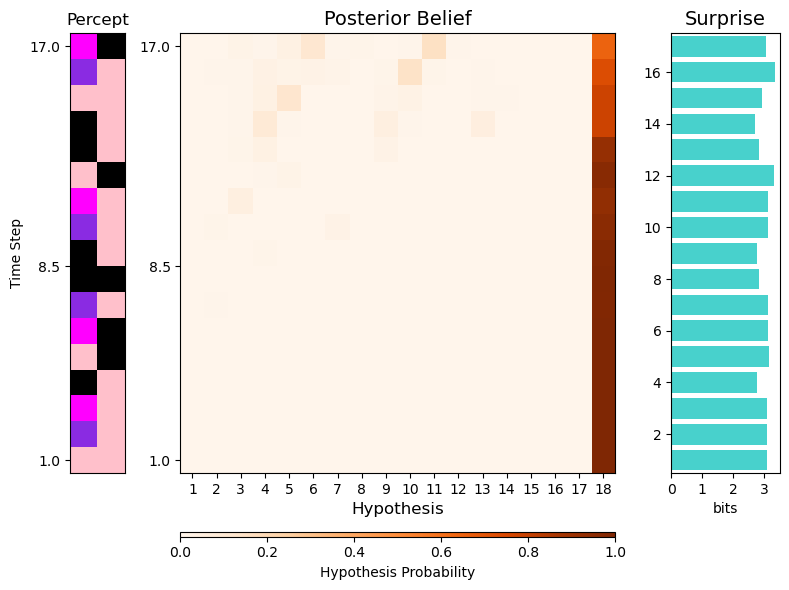

In [ ]:
moderate_memory_bias = 0.01
med_bias_AM = Associative_Memory(
    category_sizes= new_percept_category_sizes,
    memory_capacity= num_percepts,                         
    memory_bias = moderate_memory_bias,
    fading_rate = fading_rate,
    surprise_factor = high_suprise_factor,        
    consolidation_rate = no_consolidation,                
    reencoding_rate = high_reencoding_rate,               
    reassociation_rate = high_reassociation_rate,              #changed from previous AM example
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'learned',                  #changed from previous AM example, see next section on memory bias
    data_record = ['all'],
    record_until = num_percepts
)
#Simulate
for i in range(num_percepts):
    percept = noisy_percept_sequence[i,:]
    med_bias_AM.sample(percept)

memory_filter_performance(med_bias_AM.data_dic, noisy_percept_sequence,colormap)

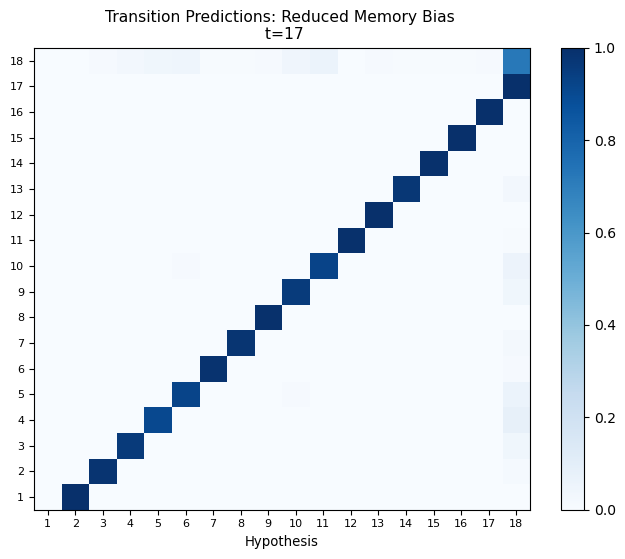

In [80]:
plot_heatmap(
    med_bias_AM.transition_predictions,
    title = "Transition Predictions: Reduced Memory Bias \n t=17",
    xlabel = "Hypothesis",
    ylabel = None,
    color = "Blues",
    label_scale = 0.8,
    vmin = 0., 
    vmax = 1., #sets scale of colorbar
    )

The lower memory bias significantly lowers the reactivation of memory traces (at least initially). Where the stationary hypothesis does predict with meaningful probability transitions to memory-based hypotheses, it is largely to those hypotheses that have been re-activated, and thus positive reassociation has occured.

As a general rule of thumb, small memory bias is good for associative memory graphs - it leaves most of the work up to learning. For very small memory biases, it can time time for the graph to "warm-up" and allow enough probability of memory-based hypotheses that learning can occur. This may not be a bad thing, as it might give memory graphs time to collect enough experiences that early learning does not result in strong biases, surperstitions, or steroeotypes.

### A longer Example

Now that we have a better sense of how re-association works, let's examine how it behaves in the example where the list sequence is repeated. We will use the same parameters for the memory graph.

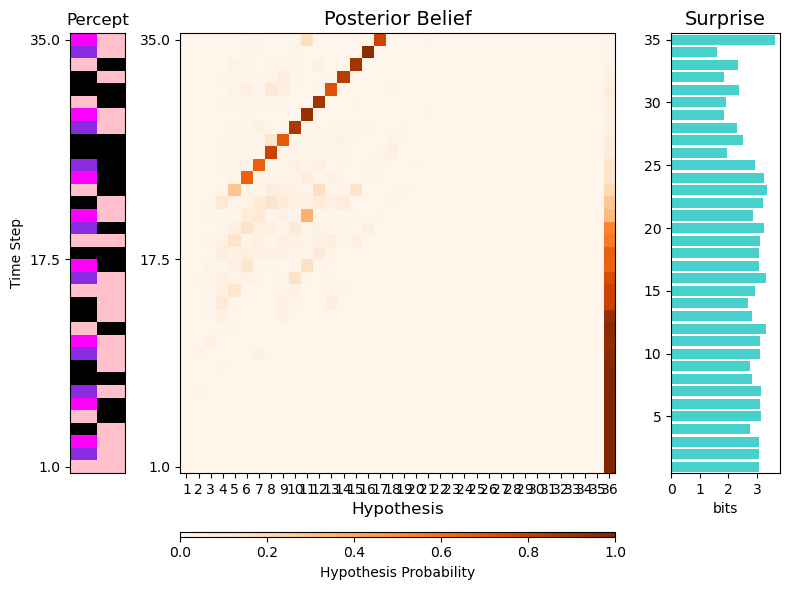

In [ ]:
twice_repeated_AM = Associative_Memory(
    category_sizes= new_percept_category_sizes,
    memory_capacity= num_percepts_repeated,                         
    memory_bias = moderate_memory_bias,
    fading_rate = fading_rate,
    surprise_factor = high_suprise_factor,        
    consolidation_rate = no_consolidation,                
    reencoding_rate = high_reencoding_rate,               
    reassociation_rate = high_reassociation_rate,              
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'learned',                 
    data_record = ['all'],
    record_until = num_percepts_repeated
)
#Simulate

for i in range(num_percepts_repeated):
    percept = repeated_lists_percepts[i,:]
    twice_repeated_AM.sample(percept)

memory_filter_performance(twice_repeated_AM.data_dic, repeated_lists_percepts, colormap)

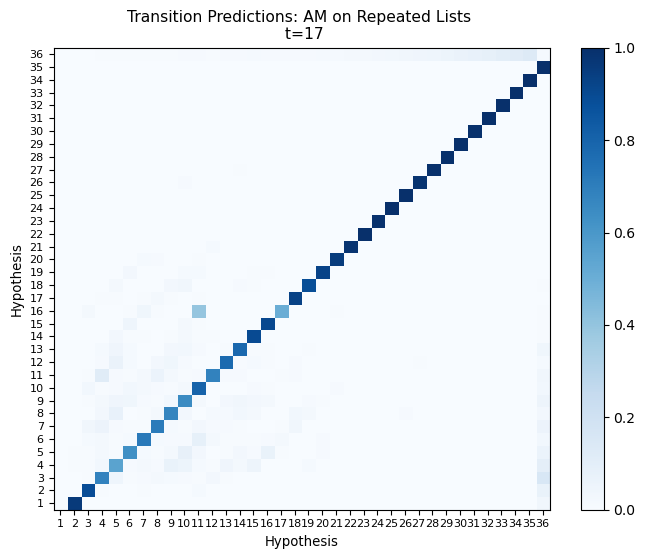

In [ ]:
plot_heatmap(
    twice_repeated_AM.transition_predictions,
    title = "Transition Predictions: AM on Repeated List Sequence \n t=17",
    xlabel = "Hypothesis",
    ylabel = "Hypothesis",
    color = "Blues",
    label_scale = 0.8,
    vmin = 0., 
    vmax = 1., #sets scale of colorbar
    )


We can see that the Associative Memory retains the ability to pick up on the repeating sequence - but now it also picks up on a coincidentally similar subsequence within the lists. It is now capable of modelling the possibility that it's situations are not strictly sequential, but that a given situation - best illustrated here by the 16th memory trace - may probabilistically lead to multiple others.

To this point, we have laregly look at exagerated paramterization to highlight the mechanics of memory graphs in short simulations. But what if we put everything together and look at the behavior of associative memory in a longer simulation?

## The Value of Associative Memory

Waaaay back when we introduced the notion of the list sequence, we described two types of percepts: the list item and the timeout. A reasonable model of an environment that produces such percept sequences might represent each position in a list as a situation and the "timeout" as a single situation (where the self-directed transition prediction produces a binomial distribution in timeout length). The associative memory graph can form such a model.

Let us generate a sequence of fifteen three-category lists and simulate an associative memory graph with some good rule-of-thumb paramter settings. These rules-of-thumb are based off of limited exploratory analysis.

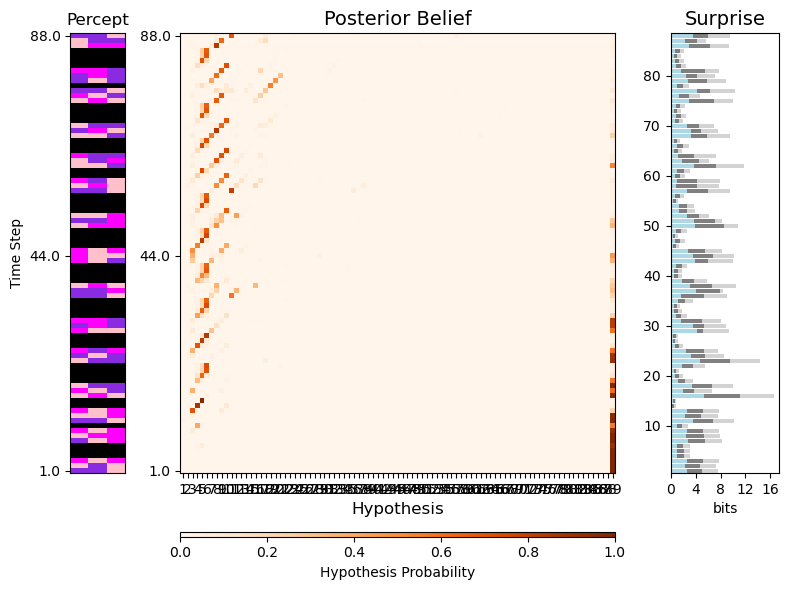

In [90]:
#Set up long List Sequence
seed = 1452081025
Long_Sequence_List = List_Sequencer(
    item_size = 3,
    item_category_size = 3,
    series_length = 3,
    mean_timeout_interval=3,
    var_time_out_interval=1,
    num_series = 15,
    seed = seed
)
num_percepts_long = np.shape(Long_Sequence_List.percept_sequence)[0]
stationary_expectations_long = Long_Sequence_List.get_stationary_state_distribution() @ Long_Sequence_List.factorized_observation_function

#Set up Associative Memory
long_sequence_category_sizes = Long_Sequence_List.percept_category_sizes
low_memory_bias = 0.001             #Rule of thumb: best between 0.01 and 0.0001. Larger values generally bias toward the reactivation of recent memories
moderate_fading_rate = 0.01         #Rule of thumb: should balance the expected time between situational recurrence and memory capacity. Very forgiving below 0.01, provided sufficient capacity
moderate_consolidation = 0.2        #Rule of thumb: best between 0.1-0.2
moderate_reencoding = 0.2           #Rule of thumb: best between 0.1-0.2
moderate_reassociation = 0.2        #Rule of thumb: best between 0.1-0.2

long_sequence_AM = Associative_Memory(
    category_sizes= long_sequence_category_sizes,               #changed from previous AM example
    memory_capacity= num_percepts_long,                         #changed from previous AM example
    memory_bias = low_memory_bias,                              #changed from previous AM example
    fading_rate = moderate_fading_rate,                         #Changed from previous AM example
    surprise_factor = high_suprise_factor,                      #Rule of thumb: Always high (between 0.95-0.999)
    consolidation_rate = moderate_consolidation,                #changed from previous AM example
    reencoding_rate = moderate_reencoding,                      #changed from previous AM example    
    reassociation_rate = moderate_reassociation,                #changed from previous AM example
    stationary_expectations = stationary_expectations_long,     #changed from previous AM example               
    data_record = ['all'],
    record_until = num_percepts_long                        #changed from previous AM example
)

for i in range(num_percepts_long):
    percept = Long_Sequence_List.percept_sequence[i,:]
    long_sequence_AM.sample(percept)

memory_filter_performance(long_sequence_AM.data_dic, Long_Sequence_List.percept_sequence,colormap,stacked=True,bar_colors=["lightblue","grey","lightgrey"])

A few things immdiately jump out when examining the posterior belief of the associative memory graph in this simulation. First, the hardly any posterior probability is ever assigned to memory-bsed hypotehses encoded after the first twenty or so steps. Second, by the end of the simuation, hardly any posterior belief is being assigned to the stationary hypothesis by the end of the simulation. Third, posterior probability is being assigned to a single set of three or four traces during each time-out, and a single set of three or four traces during a list presentation. Fourth, when a time-out goes past the mean three-step interval, the posterior probability stays distrtibuted between to memory traces in a stable pattern. It looks like the memory graph is forming into an effective model of the environment producing its percepts!

One might also note that the surprise upon the first list item of each list is typically higher than subsequent list items. This makes sense given a good model of the environment as well - it is not possible to know how long the timeout will last, so the first list item is always a little suprising. Once the first item has been observed, however, it can be known that the next percept will also be a list item. This consequence of learning to represent the concepts of "timeout" and "list item" is what drives the emergence of primacy effects when the associative memory graph is probed for previously seen list items, which we explore in another tutorial here: (add link when finished).

What do these learned representations look like? Because the memory graph is only reactivating the first twenty or so memory traces, we visualize the corresponding subset of predictions.

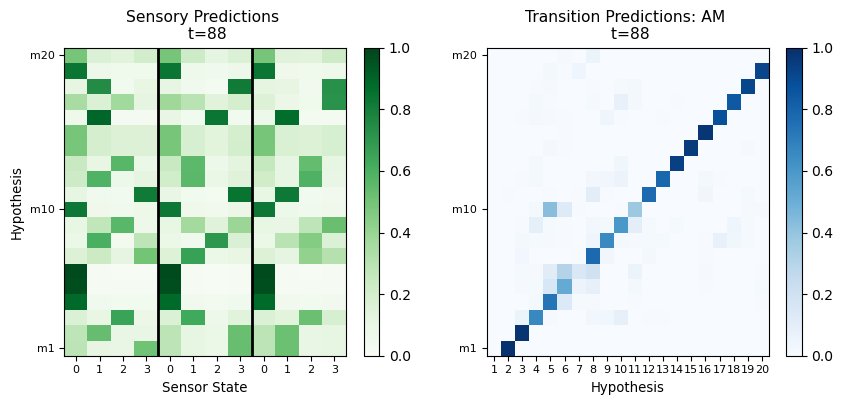

In [ ]:
#Visualize sensory predictions of LTM with and without memory consolodation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

#Sensory Predictions
plot_heatmap(
    long_sequence_AM.sensory_predictions[:20,:],
    title = "Sensory Predictions (Subset) \n t=88",
    xlabel = "Sensor State",
    xtick_labels= ["0","1","2","3"]  * 3,
    ylabel = "Hypothesis",
    yticks = [0.5,9.5,19.5],
    ytick_labels= ["m1","m10", "m20"],
    color = "Greens",
    label_scale = 0.8,
    vmin = 0., 
    vmax = 1., #sets scale of colorbar
    ax = ax1,
    category_sizes = long_sequence_category_sizes)

#Transition Predictions
plot_heatmap(
    long_sequence_AM.transition_predictions[:20,:20],
    title = "Transition Predictions (Subset) \n t=88",
    xlabel = "Hypothesis",
    ylabel = None,
    yticks = [0.5,9.5,19.5],
    ytick_labels= ["m1","m10", "m20"],
    color = "Blues",
    label_scale = 0.8,
    vmin = 0., 
    vmax = 1., #sets scale of colorbar
    ax = ax2)

plt.tight_layout
pass

One can see how the memory traces from the first timeout (hypotheses 4-6) have come to represent the concept of a timeout more generally (with some assistance from hypothesis ten - which initially encoded the start of the second timeout). By learning to predict transitions back to hypothesis 5 and 6, the memory graph has grown closer to representing a model for the binomially distributed timeout lengths.

One can also see, by looking at the snesory predictions for memory traces 7-9 that these traces have grown closer to representing the general notion of list item. Because these traces re-activated during each list presentation (a little at first, then more and more) and the state of each percept category is randomly distributed over states 1-3, the memory reencoding has led to more even predictions across these states. The probability of the timeout state in these hypotheses, however, remains low.

When we put all the components of our memory graphs together into an Associative Memory Graph and select values for its six interpretable paremeters that roughly approximate general properties of the environment, the memory graph will shape itself into a model of the environment through a memory-based process of learning.

## Where Associative Memory Fails

-To be developed.